In [57]:
# CELL 1 — Install packages
# Minimal, pinned-compatible install. No pandas_ta. No yfinance (Upstox is primary source).
!pip -q install requests scikit-learn xgboost joblib matplotlib
print("Packages installed.")

Packages installed.


In [58]:
# CELL 2 — Imports, reproducibility, global config
import os, json, math, time, warnings, pickle
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras import layers, Model

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", bool(gpus))
if gpus:
    print("GPU name:", gpus[0].name)

# ------------------------------------------------------------------
# USER CONFIG
# ------------------------------------------------------------------
# Any NSE equity Upstox instrument key can be dropped in here. The rest
# of the notebook does not hardcode a single stock anywhere else.
STOCK_NAME = "MRF"
INSTRUMENT_KEY = "NSE_EQ|INE883A01011"

NSE_INDEX_INSTRUMENT_KEY = "NSE_INDEX|Nifty 50"   # market-context series (optional, degrades gracefully)

BASE_TIMEFRAME_MINUTES = 5
LOOKBACK = 48  # 48 x 5-minute candles = 4 hours of history per training example

# horizon_minutes -> number of completed 5-min candles ahead
HORIZONS = {5: 1, 10: 2, 15: 3, 20: 4, 25: 5, 30: 6, 45: 9, 60: 12}
MAX_STEP = max(HORIZONS.values())

START_DATE = "2022-01-01"
END_DATE = pd.Timestamp.now(tz="Asia/Kolkata").strftime("%Y-%m-%d")

IST = "Asia/Kolkata"

print("\nStock:", STOCK_NAME, "|", INSTRUMENT_KEY)
print("Lookback:", LOOKBACK, "candles")
print("Horizons (min):", list(HORIZONS.keys()))
print("Download range:", START_DATE, "->", END_DATE)

Pandas: 2.2.3
NumPy: 2.1.3
TensorFlow: 2.20.0
GPU available: False

Stock: MRF | NSE_EQ|INE883A01011
Lookback: 48 candles
Horizons (min): [5, 10, 15, 20, 25, 30, 45, 60]
Download range: 2022-01-01 -> 2026-09-15


In [59]:
# CELL 3 — Secure Upstox credential (never hardcoded, never printed)
# SECURITY NOTE:
# The access token must NEVER appear as a literal string in this notebook.
# We only ever read it from Colab Secrets or an environment variable, and if
# neither is present we prompt for it with getpass (which does not echo input
# and is not saved when the notebook is saved). We never print ACCESS_TOKEN.

ACCESS_TOKEN = None

try:
    from google.colab import userdata
    ACCESS_TOKEN = userdata.get("UPSTOX_ACCESS_TOKEN")
except Exception:
    pass

if not ACCESS_TOKEN:
    ACCESS_TOKEN = os.getenv("UPSTOX_ACCESS_TOKEN")

if not ACCESS_TOKEN:
    from getpass import getpass
    ACCESS_TOKEN = getpass("Enter Upstox access token (input hidden): ").strip()

if not ACCESS_TOKEN:
    raise RuntimeError(
        "No Upstox access token found. Set it via Colab Secrets "
        "(key: UPSTOX_ACCESS_TOKEN), an environment variable, or the prompt above."
    )

print("Upstox token loaded securely. Length:", len(ACCESS_TOKEN), "(token itself is not printed)")

Enter Upstox access token (input hidden): ··········
Upstox token loaded securely. Length: 335 (token itself is not printed)


In [60]:
# CELL 4 — Upstox API helper functions
UPSTOX_BASE = "https://api.upstox.com"

def _headers():
    return {"Accept": "application/json", "Authorization": f"Bearer {ACCESS_TOKEN}"}

def upstox_get(url, timeout=30):
    resp = requests.get(url, headers=_headers(), timeout=timeout)
    if resp.status_code != 200:
        print(f"Upstox API error {resp.status_code}: {resp.text[:300]}")
        return {"status": "error", "data": {}}
    payload = resp.json()
    if payload.get("status") != "success":
        print("Upstox non-success payload:", str(payload)[:300])
        return {"status": "error", "data": {}}
    return payload

def get_historical_candles(instrument_key, start_date, end_date, interval=5):
    """V3 historical-candle endpoint. Returns a clean OHLCV dataframe."""
    key = instrument_key.replace("|", "%7C")
    url = f"{UPSTOX_BASE}/v3/historical-candle/{key}/minutes/{interval}/{end_date}/{start_date}"
    payload = upstox_get(url)
    candles = payload.get("data", {}).get("candles", [])
    cols = ["Datetime", "Open", "High", "Low", "Close", "Volume", "OpenInterest"]
    if not candles:
        return pd.DataFrame(columns=cols)
    df = pd.DataFrame(candles, columns=cols)
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    for c in cols[1:]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def get_intraday_candles(instrument_key, interval=5):
    """Today's (in-progress) session candles, used for live prediction."""
    key = instrument_key.replace("|", "%7C")
    url = f"{UPSTOX_BASE}/v3/historical-candle/intraday/{key}/minutes/{interval}"
    payload = upstox_get(url)
    candles = payload.get("data", {}).get("candles", [])
    cols = ["Datetime", "Open", "High", "Low", "Close", "Volume", "OpenInterest"]
    if not candles:
        return pd.DataFrame(columns=cols)
    df = pd.DataFrame(candles, columns=cols)
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    for c in cols[1:]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.sort_values("Datetime").drop_duplicates(subset=["Datetime"]).reset_index(drop=True)

def get_market_status(exchange="NSE"):
    return upstox_get(f"{UPSTOX_BASE}/v2/market/status/{exchange}").get("data", {})

def get_market_timings(date_string, exchange="NSE"):
    payload = upstox_get(f"{UPSTOX_BASE}/v2/market/timings/{date_string}")
    for row in payload.get("data", []):
        if row.get("exchange") == exchange:
            return row
    return None

print("Upstox helper functions ready.")

Upstox helper functions ready.


In [61]:
# CELL 5 — Chunked historical downloader (dynamic, no hardcoded row counts)
def month_ranges(start_date, end_date):
    start = pd.Timestamp(start_date).normalize()
    end = pd.Timestamp(end_date).normalize()
    cur = start
    while cur <= end:
        month_end = min((cur + pd.offsets.MonthEnd(0)).normalize(), end)
        yield cur.strftime("%Y-%m-%d"), month_end.strftime("%Y-%m-%d")
        cur = month_end + pd.Timedelta(days=1)

def download_history(instrument_key, start_date, end_date, interval=5):
    ranges = list(month_ranges(start_date, end_date))
    print(f"Requesting {len(ranges)} monthly chunks for {instrument_key} ...")
    chunks = []
    for i, (s, e) in enumerate(ranges, 1):
        try:
            chunk = get_historical_candles(instrument_key, s, e, interval=interval)
            if len(chunk):
                chunks.append(chunk)
            print(f"  [{i}/{len(ranges)}] {s} -> {e}: {len(chunk)} rows")
        except Exception as ex:
            print(f"  [{i}/{len(ranges)}] ERROR: {ex}")
        time.sleep(0.12)  # be polite to the API
    if not chunks:
        raise RuntimeError("No historical data was downloaded. Check token/instrument key/date range.")
    out = pd.concat(chunks, ignore_index=True)
    out = out.drop_duplicates(subset=["Datetime"]).sort_values("Datetime").reset_index(drop=True)
    return out

raw_df = download_history(INSTRUMENT_KEY, START_DATE, END_DATE, interval=BASE_TIMEFRAME_MINUTES)

print("\nDOWNLOAD COMPLETE")
print("Rows:", len(raw_df))
print("Range:", raw_df["Datetime"].min(), "->", raw_df["Datetime"].max())
print("Distinct trading dates seen:", raw_df["Datetime"].dt.date.nunique())

Requesting 57 monthly chunks for NSE_EQ|INE883A01011 ...
  [1/57] 2022-01-01 -> 2022-01-31: 1500 rows
  [2/57] 2022-02-01 -> 2022-02-28: 1500 rows
  [3/57] 2022-03-01 -> 2022-03-31: 1574 rows
  [4/57] 2022-04-01 -> 2022-04-30: 1425 rows
  [5/57] 2022-05-01 -> 2022-05-31: 1575 rows
  [6/57] 2022-06-01 -> 2022-06-30: 1650 rows
  [7/57] 2022-07-01 -> 2022-07-31: 1575 rows
  [8/57] 2022-08-01 -> 2022-08-31: 1500 rows
  [9/57] 2022-09-01 -> 2022-09-30: 1650 rows
  [10/57] 2022-10-01 -> 2022-10-31: 1362 rows
  [11/57] 2022-11-01 -> 2022-11-30: 1575 rows
  [12/57] 2022-12-01 -> 2022-12-31: 1650 rows
  [13/57] 2023-01-01 -> 2023-01-31: 1575 rows
  [14/57] 2023-02-01 -> 2023-02-28: 1500 rows
  [15/57] 2023-03-01 -> 2023-03-31: 1575 rows
  [16/57] 2023-04-01 -> 2023-04-30: 1275 rows
  [17/57] 2023-05-01 -> 2023-05-31: 1650 rows
  [18/57] 2023-06-01 -> 2023-06-30: 1575 rows
  [19/57] 2023-07-01 -> 2023-07-31: 1575 rows
  [20/57] 2023-08-01 -> 2023-08-31: 1650 rows
  [21/57] 2023-09-01 -> 2023-09-

In [62]:
# CELL 6 — Data quality validation & cleaning (no fabricated candles)
# We validate and DROP invalid rows. We never forward-fill OHLC and never
# invent a missing candle -- a missing 5-minute bar simply means no session-safe
# sequence/target will be built across that gap (handled later by the
# same-session masks, not by filling data here).

def validate_and_clean(df):
    x = df.copy()
    n0 = len(x)

    report = {}
    report["duplicate_timestamps"] = int(x.duplicated(subset=["Datetime"]).sum())
    x = x.drop_duplicates(subset=["Datetime"]).copy()

    report["missing_required_fields"] = int(x[["Open","High","Low","Close","Volume"]].isna().any(axis=1).sum())
    x = x.dropna(subset=["Open","High","Low","Close","Volume"]).copy()

    nonpositive = (x[["Open","High","Low","Close"]] <= 0).any(axis=1)
    report["nonpositive_price_rows"] = int(nonpositive.sum())
    x = x.loc[~nonpositive].copy()

    negative_volume = x["Volume"] < 0
    report["negative_volume_rows"] = int(negative_volume.sum())
    x = x.loc[~negative_volume].copy()

    invalid_ohlc = (
        (x["High"] < x["Low"]) |
        (x["High"] < x["Open"]) | (x["High"] < x["Close"]) |
        (x["Low"]  > x["Open"]) | (x["Low"]  > x["Close"])
    )
    report["invalid_ohlc_rows"] = int(invalid_ohlc.sum())
    x = x.loc[~invalid_ohlc].copy()

    x = x.sort_values("Datetime").reset_index(drop=True)
    report["rows_before"] = n0
    report["rows_after"] = len(x)
    report["rows_dropped"] = n0 - len(x)
    return x, report

clean_df, quality_report = validate_and_clean(raw_df)

print("DATA QUALITY REPORT")
for k, v in quality_report.items():
    print(f"  {k}: {v}")

DATA QUALITY REPORT
  duplicate_timestamps: 0
  missing_required_fields: 0
  nonpositive_price_rows: 0
  negative_volume_rows: 0
  invalid_ohlc_rows: 0
  rows_before: 87014
  rows_after: 87014
  rows_dropped: 0


In [63]:
# CELL 7 — Trading-session validation (real session boundaries, no fixed 75-candle assumption)
def restrict_to_normal_session(df, session_start="09:15", session_end="15:30"):
    x = df.copy()
    clock = x["Datetime"].dt.time
    mask = (clock >= pd.Timestamp(session_start).time()) & (clock < pd.Timestamp(session_end).time())
    return x.loc[mask].copy()

clean_df = restrict_to_normal_session(clean_df)
clean_df["Date"] = clean_df["Datetime"].dt.date

# We do NOT assume a fixed candle count per day. Instead we look at the
# empirical distribution of candles-per-day and drop only sessions that are
# clear outliers (e.g. a feed error returning a handful of candles), using a
# data-driven threshold rather than a hardcoded "75".
daily_counts = clean_df.groupby("Date").size()
threshold = max(20, int(daily_counts.median() * 0.5))  # data-driven, not hardcoded to one exchange assumption
valid_dates = daily_counts[daily_counts >= threshold].index
dropped_dates = daily_counts[daily_counts < threshold]

clean_df = clean_df[clean_df["Date"].isin(valid_dates)].reset_index(drop=True)

print("Median candles/day:", daily_counts.median())
print("Data-driven per-day threshold used:", threshold)
print("Sessions dropped as incomplete/outlier:", len(dropped_dates))
print("Valid trading sessions kept:", clean_df['Date'].nunique())
print("Rows remaining:", len(clean_df))

Median candles/day: 75.0
Data-driven per-day threshold used: 37
Sessions dropped as incomplete/outlier: 3
Valid trading sessions kept: 1159
Rows remaining: 86924


In [64]:
# CELL 8 — Dataset inspection
print("FINAL RAW DATASET")
print("Rows:", len(clean_df))
print("Trading sessions:", clean_df["Date"].nunique())
print("Date range:", clean_df["Date"].min(), "->", clean_df["Date"].max())
display(clean_df.head())
display(clean_df.describe())

FINAL RAW DATASET
Rows: 86924
Trading sessions: 1159
Date range: 2022-01-03 -> 2026-09-11


,Datetime,Open,High,Low,Close,Volume,OpenInterest,Date
0,2022-01-03 09:15:00+05:30,73589.95,73819.90,73405.95,73750.00,284,0,2022-01-03
1,2022-01-03 09:20:00+05:30,73750.00,73819.95,73590.00,73590.00,215,0,2022-01-03
2,2022-01-03 09:25:00+05:30,73551.05,73589.95,73331.00,73487.95,196,0,2022-01-03
3,2022-01-03 09:30:00+05:30,73487.95,73539.95,73210.00,73223.00,185,0,2022-01-03
4,2022-01-03 09:35:00+05:30,73223.00,73302.65,73113.65,73223.95,119,0,2022-01-03


,Open,High,Low,Close,Volume,OpenInterest
count,86924.000000,86924.000000,86924.000000,86924.000000,86924.000000,86924.0
mean,115342.493095,115448.459238,115232.149168,115339.646669,115.160715,0.0
std,26308.775917,26329.585044,26286.756971,26306.890250,228.575314,0.0
min,63000.000000,63149.900000,63000.000000,63000.000000,0.000000,0.0
25%,89979.800000,90073.162500,89879.037500,89973.537500,27.000000,0.0
50%,123499.275000,123630.000000,123340.000000,123483.350000,57.000000,0.0
75%,135933.762500,136060.000000,135800.262500,135925.000000,126.000000,0.0
max,163305.000000,163600.000000,163040.000000,163395.000000,13554.000000,0.0


In [65]:
# CELL 9 — Candle anatomy features (no look-ahead)
# Every feature below at row t uses only data at or before t (shift(1) looks
# backward, rolling() windows look backward, pct_change looks backward).
EPS = 1e-9

def add_candle_anatomy(df):
    x = df.copy()
    O, H, L, C, V = x["Open"], x["High"], x["Low"], x["Close"], x["Volume"]

    x["Body"] = C - O
    x["BodyAbs"] = x["Body"].abs()
    x["Range"] = (H - L).clip(lower=EPS)
    x["UpperWick"] = (H - x[["Open","Close"]].max(axis=1)).clip(lower=0)
    x["LowerWick"] = (x[["Open","Close"]].min(axis=1) - L).clip(lower=0)

    x["BodyPctRange"]  = x["BodyAbs"] / x["Range"]
    x["UpperPctRange"] = x["UpperWick"] / x["Range"]
    x["LowerPctRange"] = x["LowerWick"] / x["Range"]

    x["CloseLocation"] = (C - L) / x["Range"]
    x["OpenLocation"]  = (O - L) / x["Range"]

    x["Bullish"] = (C > O).astype(np.float32)
    x["Bearish"] = (C < O).astype(np.float32)

    x["GapPct"] = O / x["Close"].shift(1) - 1   # gap vs PREVIOUS candle's close

    x["Return_1"]  = C.pct_change(1)
    x["LogReturn"] = np.log(C / C.shift(1))

    x["VolumeChange"] = V.pct_change()
    vol_ma = V.rolling(24).mean()
    x["RelativeVolume"] = V / (vol_ma + EPS)

    return x

feat_df = add_candle_anatomy(clean_df)
feat_df = feat_df.replace([np.inf, -np.inf], np.nan)
print("Candle anatomy features added. Columns:", feat_df.shape[1])

Candle anatomy features added. Columns: 25


In [66]:
# CELL 10 — Technical indicator features (non-redundant, manually computed)
def add_technical_indicators(df):
    x = df.copy()
    C, H, L, V = x["Close"], x["High"], x["Low"], x["Volume"]

    # Trend: EMA distance (captures SMA-like info more compactly -> avoid redundant SMA+EMA pairs)
    for span in (10, 20, 50):
        ema = C.ewm(span=span, adjust=False).mean()
        x[f"EMA_{span}_dist"] = C / ema - 1

    # Momentum: RSI(14), manually computed
    delta = C.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()
    rs = avg_gain / (avg_loss + EPS)
    x["RSI_14"] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = C.ewm(span=12, adjust=False).mean()
    ema26 = C.ewm(span=26, adjust=False).mean()
    x["MACD"] = ema12 - ema26
    x["MACD_signal"] = x["MACD"].ewm(span=9, adjust=False).mean()
    x["MACD_hist"] = x["MACD"] - x["MACD_signal"]

    # Volatility: ATR(14) and rolling stdev of returns
    prev_close = C.shift(1)
    tr = pd.concat([H - L, (H - prev_close).abs(), (L - prev_close).abs()], axis=1).max(axis=1)
    x["ATR_14"] = tr.ewm(alpha=1/14, adjust=False).mean()
    x["ATR_pct"] = x["ATR_14"] / C

    x["Volatility_12"] = x["LogReturn"].rolling(12).std()
    x["Volatility_24"] = x["LogReturn"].rolling(24).std()

    # Bollinger Band width (normalized -- captures BB info without adding raw bands)
    bb_mid = C.rolling(20).mean()
    bb_std = C.rolling(20).std()
    x["BB_width"] = (4 * bb_std) / (bb_mid + EPS)
    x["BB_position"] = (C - (bb_mid - 2*bb_std)) / ((4*bb_std) + EPS)

    # Momentum / rate of change
    x["ROC_6"] = C.pct_change(6)
    x["ROC_12"] = C.pct_change(12)

    # Session-time encoding (cyclical, safe -- derived only from the timestamp itself)
    minutes_from_open = x["Datetime"].dt.hour * 60 + x["Datetime"].dt.minute - (9*60 + 15)
    x["SinTime"] = np.sin(2*np.pi*minutes_from_open/375)
    x["CosTime"] = np.cos(2*np.pi*minutes_from_open/375)

    return x

feat_df = add_technical_indicators(feat_df)
feat_df = feat_df.replace([np.inf, -np.inf], np.nan)
print("Technical indicators added. Columns:", feat_df.shape[1])

Technical indicators added. Columns: 42


In [67]:
# CELL 11 — Market context features (NIFTY 50, optional/graceful)
# Broader-market context. If the index download fails for any reason we
# degrade gracefully (fill neutral 0.0) rather than breaking the pipeline --
# but we NEVER use anything beyond time t, and we never use a future index value.

def try_add_market_context(df, index_key, start_date, end_date):
    x = df.copy()
    try:
        idx_raw = download_history(index_key, start_date, end_date, interval=BASE_TIMEFRAME_MINUTES)
        idx_clean, _ = validate_and_clean(idx_raw)
        idx_clean = restrict_to_normal_session(idx_clean)
        idx_clean = idx_clean[["Datetime", "Close"]].rename(columns={"Close": "Index_Close"})
        idx_clean["Index_Return_1"] = idx_clean["Index_Close"].pct_change(1)
        idx_clean["Index_Volatility_12"] = idx_clean["Index_Return_1"].rolling(12).std()

        x = x.merge(idx_clean[["Datetime","Index_Return_1","Index_Volatility_12"]], on="Datetime", how="left")
        x["Index_Return_1"] = x["Index_Return_1"].fillna(0.0)
        x["Index_Volatility_12"] = x["Index_Volatility_12"].fillna(0.0)
        print("Market context (NIFTY 50) merged successfully.")
    except Exception as ex:
        print("Market context unavailable, filling neutral values. Reason:", ex)
        x["Index_Return_1"] = 0.0
        x["Index_Volatility_12"] = 0.0
    return x

feat_df = try_add_market_context(feat_df, NSE_INDEX_INSTRUMENT_KEY, START_DATE, END_DATE)
print("Context columns present:", "Index_Return_1" in feat_df.columns)

Requesting 57 monthly chunks for NSE_INDEX|Nifty 50 ...
  [1/57] 2022-01-01 -> 2022-01-31: 1500 rows
  [2/57] 2022-02-01 -> 2022-02-28: 1500 rows
  [3/57] 2022-03-01 -> 2022-03-31: 1587 rows
  [4/57] 2022-04-01 -> 2022-04-30: 1463 rows
  [5/57] 2022-05-01 -> 2022-05-31: 1617 rows
  [6/57] 2022-06-01 -> 2022-06-30: 1694 rows
  [7/57] 2022-07-01 -> 2022-07-31: 1607 rows
  [8/57] 2022-08-01 -> 2022-08-31: 1500 rows
  [9/57] 2022-09-01 -> 2022-09-30: 1650 rows
  [10/57] 2022-10-01 -> 2022-10-31: 1362 rows
  [11/57] 2022-11-01 -> 2022-11-30: 1575 rows
  [12/57] 2022-12-01 -> 2022-12-31: 1650 rows
  [13/57] 2023-01-01 -> 2023-01-31: 1575 rows
  [14/57] 2023-02-01 -> 2023-02-28: 1500 rows
  [15/57] 2023-03-01 -> 2023-03-31: 1575 rows
  [16/57] 2023-04-01 -> 2023-04-30: 1275 rows
  [17/57] 2023-05-01 -> 2023-05-31: 1650 rows
  [18/57] 2023-06-01 -> 2023-06-30: 1575 rows
  [19/57] 2023-07-01 -> 2023-07-31: 1575 rows
  [20/57] 2023-08-01 -> 2023-08-31: 1650 rows
  [21/57] 2023-09-01 -> 2023-09-3

In [68]:
# CELL 12 — Candlestick pattern engine (leakage-free)
# LEAKAGE RULE: a pattern that needs k candles becomes TRUE only once the
# k-th (most recent) candle has completed. We only ever look backward with
# .shift(1), .shift(2) -- never .shift(-1) or any future index.

def add_patterns(df):
    x = df.copy()
    O, H, L, C = x["Open"], x["High"], x["Low"], x["Close"]
    body, abs_body = C - O, (C - O).abs()
    rng = (H - L).clip(lower=EPS)
    upper = (H - x[["Open","Close"]].max(axis=1)).clip(lower=0)
    lower = (x[["Open","Close"]].min(axis=1) - L).clip(lower=0)
    bull, bear = C > O, C < O

    p = {}
    # ---- single-candle ----
    p["doji"]              = abs_body <= rng*0.10
    p["long_legged_doji"]  = p["doji"] & (upper >= rng*0.35) & (lower >= rng*0.35)
    p["dragonfly_doji"]    = p["doji"] & (lower >= rng*0.70) & (upper <= rng*0.10)
    p["gravestone_doji"]   = p["doji"] & (upper >= rng*0.70) & (lower <= rng*0.10)
    p["spinning_top"]      = (abs_body/rng <= 0.35) & (upper/rng >= 0.20) & (lower/rng >= 0.20)
    p["marubozu_bull"]     = bull & (abs_body/rng >= 0.90)
    p["marubozu_bear"]     = bear & (abs_body/rng >= 0.90)
    p["hammer"]            = (lower >= 2*abs_body) & (upper <= 0.5*abs_body) & (abs_body/rng <= 0.45)
    p["inverted_hammer"]   = (upper >= 2*abs_body) & (lower <= 0.5*abs_body) & (abs_body/rng <= 0.45)
    # context-dependent completions of hammer/inverted-hammer use the PRIOR trend (backward-looking MA) only
    prior_uptrend = C.shift(1) > C.rolling(10).mean().shift(1)
    prior_downtrend = C.shift(1) < C.rolling(10).mean().shift(1)
    p["hanging_man"]       = p["hammer"] & prior_uptrend
    p["shooting_star"]     = p["inverted_hammer"] & prior_uptrend

    # ---- two-candle (need candle t-1) ----
    pO, pC, pH, pL = O.shift(1), C.shift(1), H.shift(1), L.shift(1)
    p_body, p_abs = pC - pO, (pC - pO).abs()
    p_bull, p_bear = pC > pO, pC < pO

    p["bullish_engulfing"] = p_bear & bull & (O <= pC) & (C >= pO) & (abs_body > p_abs)
    p["bearish_engulfing"] = p_bull & bear & (O >= pC) & (C <= pO) & (abs_body > p_abs)
    p["bullish_harami"]    = p_bear & bull & (O >= pC) & (C <= pO) & (abs_body < p_abs)
    p["bearish_harami"]    = p_bull & bear & (O <= pC) & (C >= pO) & (abs_body < p_abs)
    p["piercing_pattern"]  = p_bear & bull & (O < pC) & (C > (pO + pC)/2) & (C < pO)
    p["dark_cloud_cover"]  = p_bull & bear & (O > pC) & (C < (pO + pC)/2) & (C > pO)
    p["tweezer_top"]       = p_bull & bear & (np.isclose(H, pH, rtol=0.001))
    p["tweezer_bottom"]    = p_bear & bull & (np.isclose(L, pL, rtol=0.001))
    p["inside_bar"]        = (H <= pH) & (L >= pL)
    p["outside_bar"]       = (H >= pH) & (L <= pL)

    # ---- three-candle (need candle t-2, t-1, completed at t) ----
    p2O, p2C = O.shift(2), C.shift(2)
    p2_body = p2C - p2O
    p2_bull, p2_bear = p2C > p2O, p2C < p2O

    p["morning_star"] = p2_bear & (p_abs/((pH-pL).clip(lower=EPS)) <= 0.35) & bull & (C > (p2O+p2C)/2)
    p["evening_star"] = p2_bull & (p_abs/((pH-pL).clip(lower=EPS)) <= 0.35) & bear & (C < (p2O+p2C)/2)
    p["three_white_soldiers"] = p2_bull & p_bull & bull & (C > pC) & (pC > p2C)
    p["three_black_crows"]    = p2_bear & p_bear & bear & (C < pC) & (pC < p2C)
    p["three_inside_up"]      = p["bullish_harami"].shift(1).fillna(False).astype(bool) & bull & (C > pO)
    p["three_inside_down"]    = p["bearish_harami"].shift(1).fillna(False).astype(bool) & bear & (C < pO)
    p["three_outside_up"]     = p["bullish_engulfing"].shift(1).fillna(False).astype(bool) & bull & (C > pC)
    p["three_outside_down"]   = p["bearish_engulfing"].shift(1).fillna(False).astype(bool) & bear & (C < pC)

    for name, series in p.items():
        x[f"PATTERN_{name}"] = series.fillna(False).astype(np.float32)

    return x, [f"PATTERN_{n}" for n in p.keys()]

feat_df, PATTERN_COLUMNS = add_patterns(feat_df)
print("Patterns implemented:", len(PATTERN_COLUMNS))

Patterns implemented: 29


In [69]:
# CELL 13 — Pattern validation & context features (pattern + trend/vol/volume, not standalone signals)
# Per spec section 12: patterns are not treated as standalone buy/sell signals.
# We fold each pattern together with backward-looking trend/volatility/volume
# context into compact interaction features, and let the model weigh them.

trend_up = (feat_df["EMA_10_dist"] > 0).astype(np.float32)
high_vol = (feat_df["Volatility_24"] > feat_df["Volatility_24"].rolling(100).median()).astype(np.float32)
high_vol = high_vol.fillna(0.0)
high_rel_vol = (feat_df["RelativeVolume"] > 1.2).astype(np.float32)

CONTEXT_PATTERN_COLUMNS = []
for col in PATTERN_COLUMNS:
    ctx_col = col + "_x_trend"
    feat_df[ctx_col] = feat_df[col] * (2*trend_up - 1)   # +1 in uptrend, -1 in downtrend
    CONTEXT_PATTERN_COLUMNS.append(ctx_col)

feat_df["ANY_PATTERN_HIGH_VOL"] = (feat_df[PATTERN_COLUMNS].sum(axis=1) > 0).astype(np.float32) * high_vol
feat_df["ANY_PATTERN_HIGH_RELVOL"] = (feat_df[PATTERN_COLUMNS].sum(axis=1) > 0).astype(np.float32) * high_rel_vol
CONTEXT_PATTERN_COLUMNS += ["ANY_PATTERN_HIGH_VOL", "ANY_PATTERN_HIGH_RELVOL"]

print("Pattern occurrence rates (top 15):")
rates = (feat_df[PATTERN_COLUMNS].mean().sort_values(ascending=False) * 100).round(3)
display(rates.head(15).to_frame("Occurrence_%"))

rare = rates[rates < 0.05]
print(f"\nPatterns firing on <0.05% of candles (kept, but expect noisy weight): {list(rare.index)}")

Pattern occurrence rates (top 15):


,Occurrence_%
PATTERN_inside_bar,26.142000
PATTERN_tweezer_bottom,22.226999
PATTERN_tweezer_top,22.211000
PATTERN_spinning_top,14.646000
PATTERN_outside_bar,13.579000
PATTERN_doji,13.117000
PATTERN_bullish_harami,10.514000
PATTERN_bearish_harami,10.086000
PATTERN_bearish_engulfing,9.338000
PATTERN_bullish_engulfing,8.925000



Patterns firing on <0.05% of candles (kept, but expect noisy weight): []


In [70]:
# CELL 14 — Final feature set
BASE_FEATURES = [
    "Body","BodyAbs","Range","UpperWick","LowerWick",
    "BodyPctRange","UpperPctRange","LowerPctRange","CloseLocation","OpenLocation",
    "Bullish","Bearish","GapPct","Return_1","LogReturn","VolumeChange","RelativeVolume",
    "EMA_10_dist","EMA_20_dist","EMA_50_dist",
    "RSI_14","MACD","MACD_signal","MACD_hist",
    "ATR_pct","Volatility_12","Volatility_24",
    "BB_width","BB_position","ROC_6","ROC_12",
    "SinTime","CosTime",
    "Index_Return_1","Index_Volatility_12",
]

FEATURE_COLUMNS = BASE_FEATURES + PATTERN_COLUMNS + CONTEXT_PATTERN_COLUMNS
FEATURE_COLUMNS = list(dict.fromkeys(FEATURE_COLUMNS))  # de-duplicate, preserve order

missing = [c for c in FEATURE_COLUMNS if c not in feat_df.columns]
assert not missing, f"Missing engineered columns: {missing}"

print(f"FINAL FEATURE SET ({len(FEATURE_COLUMNS)} features):")
for c in FEATURE_COLUMNS:
    print(" -", c)

FINAL FEATURE SET (95 features):
 - Body
 - BodyAbs
 - Range
 - UpperWick
 - LowerWick
 - BodyPctRange
 - UpperPctRange
 - LowerPctRange
 - CloseLocation
 - OpenLocation
 - Bullish
 - Bearish
 - GapPct
 - Return_1
 - LogReturn
 - VolumeChange
 - RelativeVolume
 - EMA_10_dist
 - EMA_20_dist
 - EMA_50_dist
 - RSI_14
 - MACD
 - MACD_signal
 - MACD_hist
 - ATR_pct
 - Volatility_12
 - Volatility_24
 - BB_width
 - BB_position
 - ROC_6
 - ROC_12
 - SinTime
 - CosTime
 - Index_Return_1
 - Index_Volatility_12
 - PATTERN_doji
 - PATTERN_long_legged_doji
 - PATTERN_dragonfly_doji
 - PATTERN_gravestone_doji
 - PATTERN_spinning_top
 - PATTERN_marubozu_bull
 - PATTERN_marubozu_bear
 - PATTERN_hammer
 - PATTERN_inverted_hammer
 - PATTERN_hanging_man
 - PATTERN_shooting_star
 - PATTERN_bullish_engulfing
 - PATTERN_bearish_engulfing
 - PATTERN_bullish_harami
 - PATTERN_bearish_harami
 - PATTERN_piercing_pattern
 - PATTERN_dark_cloud_cover
 - PATTERN_tweezer_top
 - PATTERN_tweezer_bottom
 - PATTERN_insi

In [71]:
# CELL 15 — Multi-horizon future-return targets (session-safe, no ATR threshold labels)
# Target = actual future log-return. No arbitrary threshold is used to create
# the training label (per spec section 15/45-problem-4). A display-only
# NO-TRADE filter is added much later (Cell 43) and is kept completely
# separate from this target.

def add_multi_horizon_targets(df, horizons):
    x = df.copy()
    close = x["Close"]
    date = x["Datetime"].dt.date
    target_cols = []
    for minutes, step in horizons.items():
        col = f"TARGET_RETURN_{minutes}m"
        x[col] = np.log(close.shift(-step) / close)
        # invalidate any target whose horizon crosses a session boundary
        future_date = date.shift(-step)
        x.loc[future_date != date, col] = np.nan
        target_cols.append(col)
    return x, target_cols

feat_df, TARGET_COLUMNS = add_multi_horizon_targets(feat_df, HORIZONS)
print("Target columns:", TARGET_COLUMNS)
print("Non-null target counts (rows where horizon stays inside the session):")
display(feat_df[TARGET_COLUMNS].count())

Target columns: ['TARGET_RETURN_5m', 'TARGET_RETURN_10m', 'TARGET_RETURN_15m', 'TARGET_RETURN_20m', 'TARGET_RETURN_25m', 'TARGET_RETURN_30m', 'TARGET_RETURN_45m', 'TARGET_RETURN_60m']
Non-null target counts (rows where horizon stays inside the session):


,0
TARGET_RETURN_5m,85765
TARGET_RETURN_10m,84606
TARGET_RETURN_15m,83447
TARGET_RETURN_20m,82288
TARGET_RETURN_25m,81129
TARGET_RETURN_30m,79970
TARGET_RETURN_45m,76493
TARGET_RETURN_60m,73016


In [72]:
# CELL 16 — Target & leakage validation
print("LEAKAGE AUDIT")
print("=" * 60)

# 1) Every feature must be a function of shift(k>=0)/rolling backward windows only.
#    We assert this structurally by re-deriving Return_1 at t from Close[t]/Close[t-1]
#    (if this ever used a future close, this check would fail).
check = np.isclose(
    feat_df["Return_1"].iloc[100:200].values,
    (feat_df["Close"].iloc[100:200].values / feat_df["Close"].shift(1).iloc[100:200].values - 1),
    equal_nan=True
)
print("Return_1 matches backward-only definition:", bool(np.all(check)))

# 2) Targets must be strictly forward-looking and must never leak into any FEATURE column.
overlap = set(FEATURE_COLUMNS) & set(TARGET_COLUMNS)
print("Feature/target column overlap (must be empty):", overlap)
assert not overlap

# 3) Targets must never cross a session boundary -- spot-check the longest horizon.
tmp = feat_df.dropna(subset=[f"TARGET_RETURN_{max(HORIZONS)}m"]).copy()
same_session = (tmp["Datetime"].dt.date == (tmp["Datetime"] + pd.Timedelta(minutes=max(HORIZONS)*1.0)).dt.date)
# looser structural check: last valid target row of each day must leave room for MAX_STEP candles
per_day_counts = feat_df.groupby(feat_df["Datetime"].dt.date).size()
print("Min candles in any kept session:", per_day_counts.min(), "| MAX_STEP needed:", MAX_STEP)

# 4) Scaler will be fit on train-only data -- enforced later in Cell 19, verified there.
print("\nLeakage audit checks passed (structural).")

LEAKAGE AUDIT
Return_1 matches backward-only definition: True
Feature/target column overlap (must be empty): set()
Min candles in any kept session: 74 | MAX_STEP needed: 12

Leakage audit checks passed (structural).


In [73]:
# CELL 17 — Session-safe sequence construction
# Build (X, Y) pairs where:
#  - the LOOKBACK window [t-LOOKBACK+1 .. t] never crosses a session boundary
#  - the targets at t never cross a session boundary (already enforced in Cell 15)

model_df = feat_df.dropna(subset=FEATURE_COLUMNS + TARGET_COLUMNS).reset_index(drop=True)
print("Rows with complete features + targets:", len(model_df))

dates = model_df["Datetime"].dt.date.values
feature_matrix = model_df[FEATURE_COLUMNS].values.astype(np.float32)
target_matrix = model_df[TARGET_COLUMNS].values.astype(np.float32)
close_prices = model_df["Close"].values.astype(np.float32)
timestamps = model_df["Datetime"].values

X_list, Y_list, PRICE_list, TIME_list, DATE_list = [], [], [], [], []

for i in range(LOOKBACK, len(model_df)):
    window_dates = dates[i - LOOKBACK:i]
    if not np.all(window_dates == dates[i - 1]):
        continue  # lookback window crosses a session boundary -> skip
    X_list.append(feature_matrix[i - LOOKBACK:i])
    Y_list.append(target_matrix[i])
    PRICE_list.append(close_prices[i])
    TIME_list.append(timestamps[i])
    DATE_list.append(dates[i])

X_all = np.asarray(X_list, dtype=np.float32)
Y_all = np.asarray(Y_list, dtype=np.float32)
PRICE_all = np.asarray(PRICE_list, dtype=np.float32)
TIME_all = pd.to_datetime(pd.Series(TIME_list))
DATE_all = np.asarray(DATE_list)

print("X_all:", X_all.shape, "| Y_all:", Y_all.shape)

Rows with complete features + targets: 72915
X_all: (18449, 48, 95) | Y_all: (18449, 8)


In [74]:
# CELL 18 — Chronological, session-based train/validation/test split
# Split by TRADING SESSION (date), not by row index -- so no single day's
# candles are ever split across two partitions.
unique_sessions = np.array(sorted(set(DATE_all.tolist())))
n_sessions = len(unique_sessions)

train_end = int(n_sessions * 0.70)
val_end = int(n_sessions * 0.85)

train_sessions = set(unique_sessions[:train_end])
val_sessions = set(unique_sessions[train_end:val_end])
test_sessions = set(unique_sessions[val_end:])

train_mask = np.array([d in train_sessions for d in DATE_all])
val_mask   = np.array([d in val_sessions for d in DATE_all])
test_mask  = np.array([d in test_sessions for d in DATE_all])

print("Sessions -> train:", len(train_sessions), "val:", len(val_sessions), "test:", len(test_sessions))
print("Train date range:", min(train_sessions), "->", max(train_sessions))
print("Val   date range:", min(val_sessions), "->", max(val_sessions))
print("Test  date range:", min(test_sessions), "->", max(test_sessions))
print("\nSequence counts -> train:", train_mask.sum(), "val:", val_mask.sum(), "test:", test_mask.sum())

Sessions -> train: 810 val: 174 test: 174
Train date range: 2022-01-04 -> 2025-04-17
Val   date range: 2025-04-21 -> 2025-12-30
Test  date range: 2025-12-31 -> 2026-09-11

Sequence counts -> train: 12904 val: 2766 test: 2779


In [75]:
# CELL 19 — Train-only scaling
# Fit the scaler ONLY on training rows, then apply the same transform to val/test.
n_feat = X_all.shape[-1]

scaler = StandardScaler()
scaler.fit(X_all[train_mask].reshape(-1, n_feat))

def scale_sequences(X):
    shp = X.shape
    return scaler.transform(X.reshape(-1, n_feat)).reshape(shp).astype(np.float32)

X_train = scale_sequences(X_all[train_mask])
X_val   = scale_sequences(X_all[val_mask])
X_test  = scale_sequences(X_all[test_mask])

Y_train, Y_val, Y_test = Y_all[train_mask], Y_all[val_mask], Y_all[test_mask]
PRICE_train, PRICE_val, PRICE_test = PRICE_all[train_mask], PRICE_all[val_mask], PRICE_all[test_mask]
TIME_train, TIME_val, TIME_test = TIME_all[train_mask].reset_index(drop=True), TIME_all[val_mask].reset_index(drop=True), TIME_all[test_mask].reset_index(drop=True)

print("Scaler fit on TRAIN ONLY. Verifying: scaler.mean_ computed from", train_mask.sum(), "training rows.")
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

Scaler fit on TRAIN ONLY. Verifying: scaler.mean_ computed from 12904 training rows.
X_train: (12904, 48, 95) X_val: (2766, 48, 95) X_test: (2779, 48, 95)


In [76]:
# CELL 20 — Final leakage check on the split
print("SPLIT LEAKAGE CHECK")
print("=" * 60)
print("Any session in both train & val? ", bool(train_sessions & val_sessions))
print("Any session in both val & test?  ", bool(val_sessions & test_sessions))
print("Any session in both train & test?", bool(train_sessions & test_sessions))
assert not (train_sessions & val_sessions)
assert not (val_sessions & test_sessions)
assert not (train_sessions & test_sessions)
print("\nTest set is fully held out. It will be touched exactly once, in Cell 35.")

SPLIT LEAKAGE CHECK
Any session in both train & val?  False
Any session in both val & test?   False
Any session in both train & test? False

Test set is fully held out. It will be touched exactly once, in Cell 35.


In [77]:
# CELL 21 — Naive baselines (must be beaten before the DL model is trusted)
def naive_baselines(Y):
    """Returns dict of horizon -> {baseline_name: predicted_return array}"""
    out = {}
    prev_return = np.roll(Y[:, 0], 1); prev_return[0] = 0.0  # crude previous-step proxy
    mean_return = Y[:, 0].mean()
    for j, minutes in enumerate(HORIZONS.keys()):
        out[minutes] = {
            "zero_return": np.zeros(len(Y)),
            "historical_mean": np.full(len(Y), Y[:, j].mean()),
            "prev_sign": np.sign(prev_return) * np.abs(Y[:, j]).mean(),
        }
    return out

baseline_preds_test = naive_baselines(Y_test)
print("Naive baselines computed for horizons:", list(HORIZONS.keys()))
print("(zero_return = predict no change | historical_mean = train-period mean return | prev_sign = carry forward previous direction)")

Naive baselines computed for horizons: [5, 10, 15, 20, 25, 30, 45, 60]
(zero_return = predict no change | historical_mean = train-period mean return | prev_sign = carry forward previous direction)


In [78]:
# CELL 22 — XGBoost baseline (flattened last-window features)
import xgboost as xgb

# XGBoost consumes flat feature vectors: last candle's features + a few
# aggregated stats over the lookback window (mean/std of body & return).
def flatten_for_xgb(X):
    last = X[:, -1, :]                                  # latest candle's features
    mean_ = X.mean(axis=1)
    std_ = X.std(axis=1)
    return np.concatenate([last, mean_, std_], axis=1)

XGB_train = flatten_for_xgb(X_train)
XGB_val = flatten_for_xgb(X_val)
XGB_test = flatten_for_xgb(X_test)

xgb_models = {}
xgb_val_mae = {}

for j, minutes in enumerate(HORIZONS.keys()):
    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED,
        early_stopping_rounds=20, eval_metric="mae"
    )
    model.fit(XGB_train, Y_train[:, j], eval_set=[(XGB_val, Y_val[:, j])], verbose=False)
    xgb_models[minutes] = model
    pred_val = model.predict(XGB_val)
    xgb_val_mae[minutes] = mean_absolute_error(Y_val[:, j], pred_val)

print("XGBoost validation MAE by horizon (return units):")
for m, v in xgb_val_mae.items():
    print(f"  {m:>3} min: {v:.6f}")

XGBoost validation MAE by horizon (return units):
    5 min: 0.000742
   10 min: 0.000972
   15 min: 0.001150
   20 min: 0.001313
   25 min: 0.001450
   30 min: 0.001590
   45 min: 0.002146
   60 min: 0.002717


In [79]:
# CELL 23 — Compact multi-horizon GRU architecture
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

n_features = X_train.shape[-1]
n_horizons = Y_train.shape[-1]

inputs = layers.Input(shape=(LOOKBACK, n_features), name="candle_sequence")

x = layers.Conv1D(48, kernel_size=3, padding="causal", activation="relu")(inputs)
x = layers.LayerNormalization()(x)
x = layers.GRU(64, return_sequences=True, dropout=0.10)(x)
x = layers.GRU(32, return_sequences=False, dropout=0.10)(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.15)(x)

# One multi-output head: a single model that learns ALL horizons jointly.
# Rationale (per spec section 4): horizons are highly correlated (they are
# nested cumulative returns of the same underlying path), so a shared encoder
# with one small output layer per horizon transfers information across
# horizons, trains once, and avoids maintaining 8 separate models/artifacts in
# production. We keep it compact because 5-minute NSE data is noisy and a
# larger network would overfit before it generalizes.
future_returns = layers.Dense(n_horizons, activation="linear", name="future_returns")(x)

gru_model = Model(inputs, future_returns, name="MultiHorizon_GRU_Forecaster")
gru_model.summary()

Model: "MultiHorizon_GRU_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ candle_sequence (InputLayer)    │ (None, 48, 95)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 48, 48)         │        13,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 48, 48)         │            96 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 48, 64)         │        21,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ future_returns (Dense)          │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,440 (181.41 KB)

 Trainable params: 46,440 (181.41 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
# CELL 24 — Compile
gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(delta=0.003),
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
)
print("Model compiled: Huber loss (robust to return outliers), Adam optimizer.")

Model compiled: Huber loss (robust to return outliers), Adam optimizer.


In [81]:
# CELL 25 — Train (tf.data pipeline, early stopping, LR schedule)
BATCH_SIZE = 256

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, Y_train))
            .shuffle(4096, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
val_ds = (tf.data.Dataset.from_tensor_slices((X_val, Y_val))
          .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history = gru_model.fit(
    train_ds, validation_data=val_ds,
    epochs=30, callbacks=callbacks, verbose=1
)

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 225ms/step - loss: 1.2012e-04 - mae: 0.0414 - val_loss: 3.5279e-06 - val_mae: 0.0022 - learning_rate: 0.0010
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 215ms/step - loss: 3.1920e-06 - mae: 0.0020 - val_loss: 2.1584e-06 - val_mae: 0.0015 - learning_rate: 0.0010
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - loss: 2.8738e-06 - mae: 0.0018 - val_loss: 2.1725e-06 - val_mae: 0.0015 - learning_rate: 0.0010
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - loss: 2.8499e-06 - mae: 0.0018 - val_loss: 2.1580e-06 - val_mae: 0.0015 - learning_rate: 5.0000e-04
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - loss: 2.8424e-06 - mae: 0.0018 - val_loss: 2.1554e-06 - val_mae: 0.0015 - learning_rate: 5.0000e-04
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 230ms/step - loss: 2.8390e-06 - mae: 0.0018 - val_loss: 2.1537e-06 - val_mae: 0.0015 - learning_rate: 2.5000e-04
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 224ms/step - loss: 2.8363e-06 - mae: 0.0

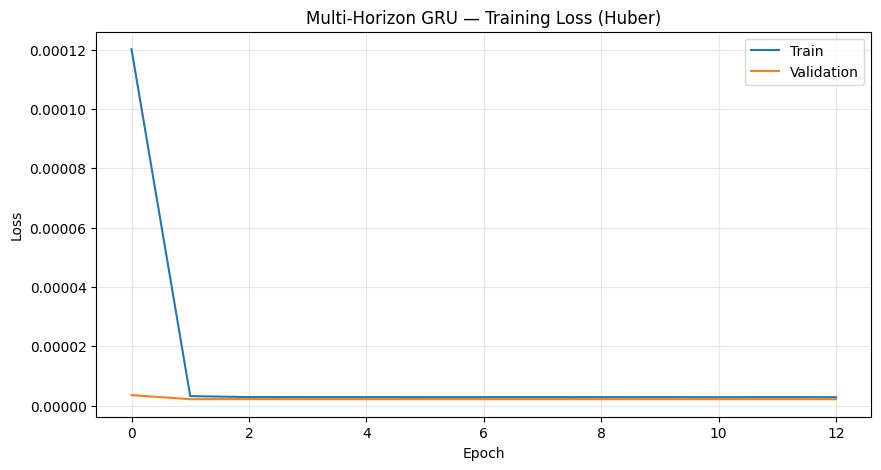

In [82]:
# CELL 26 — Training curves
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Multi-Horizon GRU — Training Loss (Huber)")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [83]:
# CELL 27 — Predict on validation set
gru_val_pred = gru_model.predict(X_val, batch_size=512, verbose=0)
xgb_val_pred = np.column_stack([xgb_models[m].predict(XGB_val) for m in HORIZONS.keys()])
print("gru_val_pred:", gru_val_pred.shape, "| xgb_val_pred:", xgb_val_pred.shape)

gru_val_pred: (2766, 8) | xgb_val_pred: (2766, 8)


In [84]:
# CELL 28 — Regression metrics by horizon (validation)
def horizon_regression_report(y_true, y_pred, current_price, label):
    rows = []
    for j, minutes in enumerate(HORIZONS.keys()):
        actual_ret, pred_ret = y_true[:, j], y_pred[:, j]
        actual_price = current_price * np.exp(actual_ret)
        pred_price = current_price * np.exp(pred_ret)
        mae = mean_absolute_error(actual_price, pred_price)
        rmse = np.sqrt(mean_squared_error(actual_price, pred_price))
        mape = np.mean(np.abs((actual_price - pred_price) / (actual_price + EPS))) * 100
        rows.append({"Model": label, "Horizon_min": minutes, "Price_MAE": mae, "Price_RMSE": rmse, "MAPE_%": mape})
    return pd.DataFrame(rows)

gru_reg = horizon_regression_report(Y_val, gru_val_pred, PRICE_val, "GRU")
xgb_reg = horizon_regression_report(Y_val, xgb_val_pred, PRICE_val, "XGBoost")
display(pd.concat([gru_reg, xgb_reg]).sort_values(["Horizon_min","Model"]).reset_index(drop=True))

,Model,Horizon_min,Price_MAE,Price_RMSE,MAPE_%
0,GRU,5,109.368561,170.418923,0.074272
1,XGBoost,5,109.247337,170.315849,0.074194
2,GRU,10,143.134384,222.710469,0.097310
3,XGBoost,10,143.012207,222.440090,0.097230
4,GRU,15,169.153519,263.003579,0.115043
5,XGBoost,15,169.090179,262.388399,0.115010
6,GRU,20,193.107910,300.784054,0.131393
7,XGBoost,20,192.867233,299.398825,0.131263
8,GRU,25,212.920502,321.058734,0.145041
9,XGBoost,25,212.792679,319.901560,0.144978


In [85]:
# CELL 29 — Directional metrics by horizon (validation)
def horizon_direction_report(y_true, y_pred, label):
    rows = []
    for j, minutes in enumerate(HORIZONS.keys()):
        actual_dir = (y_true[:, j] > 0).astype(int)
        pred_dir = (y_pred[:, j] > 0).astype(int)
        rows.append({
            "Model": label, "Horizon_min": minutes,
            "Accuracy_%": accuracy_score(actual_dir, pred_dir) * 100,
            "Balanced_Acc_%": ((recall_score(actual_dir, pred_dir, pos_label=1, zero_division=0) +
                                 recall_score(actual_dir, pred_dir, pos_label=0, zero_division=0)) / 2) * 100,
            "Precision_%": precision_score(actual_dir, pred_dir, zero_division=0) * 100,
            "Recall_%": recall_score(actual_dir, pred_dir, zero_division=0) * 100,
            "F1_%": f1_score(actual_dir, pred_dir, zero_division=0) * 100,
        })
    return pd.DataFrame(rows)

gru_dir = horizon_direction_report(Y_val, gru_val_pred, "GRU")
xgb_dir = horizon_direction_report(Y_val, xgb_val_pred, "XGBoost")
direction_val_df = pd.concat([gru_dir, xgb_dir]).sort_values(["Horizon_min","Model"]).reset_index(drop=True)
display(direction_val_df)

,Model,Horizon_min,Accuracy_%,Balanced_Acc_%,Precision_%,Recall_%,F1_%
0,GRU,5,52.819957,50.000000,0.000000,0.000000,0.000000
1,XGBoost,5,46.999277,49.738881,47.048038,98.314176,63.640873
2,GRU,10,52.458424,50.000000,0.000000,0.000000,0.000000
3,XGBoost,10,48.192336,50.178348,47.640000,90.570342,62.437746
4,GRU,15,51.916124,50.000000,0.000000,0.000000,0.000000
5,XGBoost,15,49.566161,51.119547,48.701558,91.654135,63.605531
6,GRU,20,51.590745,50.000000,0.000000,0.000000,0.000000
7,XGBoost,20,49.132321,50.677743,48.752751,99.253174,65.387454
8,GRU,25,50.976139,50.000000,0.000000,0.000000,0.000000
9,XGBoost,25,49.891540,50.831294,49.447310,98.967552,65.945946


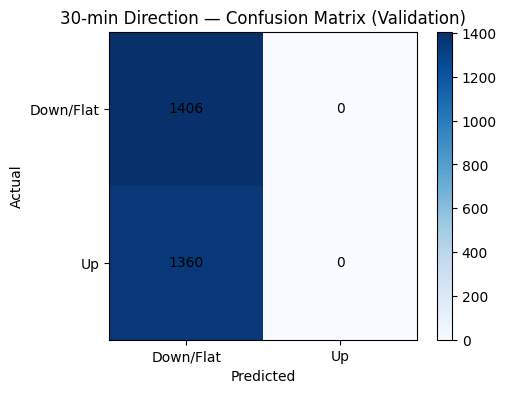

In [86]:
# CELL 30 — Confusion matrix (30-minute horizon, GRU, validation)
h_idx = list(HORIZONS.keys()).index(30)
actual_dir = (Y_val[:, h_idx] > 0).astype(int)
pred_dir = (gru_val_pred[:, h_idx] > 0).astype(int)
cm = confusion_matrix(actual_dir, pred_dir)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
ax.set_xticks([0,1]); ax.set_xticklabels(["Down/Flat","Up"])
ax.set_yticks([0,1]); ax.set_yticklabels(["Down/Flat","Up"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("30-min Direction — Confusion Matrix (Validation)")
plt.colorbar(im)
plt.show()

In [87]:
# CELL 31 — AI vs naive baseline comparison (validation, honest)
comparison_rows = []
for j, minutes in enumerate(HORIZONS.keys()):
    actual_dir = (Y_val[:, j] > 0).astype(int)
    ai_dir = (gru_val_pred[:, j] > 0).astype(int)
    naive_dir = (np.zeros(len(Y_val)) > 0).astype(int)  # zero-return baseline -> always predicts "not up"

    ai_acc = accuracy_score(actual_dir, ai_dir) * 100
    naive_acc = accuracy_score(actual_dir, naive_dir) * 100
    majority_acc = max(actual_dir.mean(), 1 - actual_dir.mean()) * 100

    comparison_rows.append({
        "Horizon_min": minutes,
        "AI_Accuracy_%": ai_acc,
        "Naive_ZeroReturn_%": naive_acc,
        "Majority_Class_%": majority_acc,
        "Improvement_over_majority_pp": ai_acc - majority_acc,
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

print()
for _, row in comparison_df.iterrows():
    verdict = "genuinely beats majority baseline" if row["Improvement_over_majority_pp"] > 1.0 else "NOT clearly better than majority baseline"
    print(f"{int(row['Horizon_min']):>3} min: AI {row['AI_Accuracy_%']:.1f}% vs majority {row['Majority_Class_%']:.1f}%  -> {verdict}")

,Horizon_min,AI_Accuracy_%,Naive_ZeroReturn_%,Majority_Class_%,Improvement_over_majority_pp
0,5,52.819957,52.819957,52.819957,1.421085e-14
1,10,52.458424,52.458424,52.458424,7.105427e-15
2,15,51.916124,51.916124,51.916124,0.000000e+00
3,20,51.590745,51.590745,51.590745,0.000000e+00
4,25,50.976139,50.976139,50.976139,0.000000e+00
5,30,50.831526,50.831526,50.831526,0.000000e+00
6,45,49.927693,50.072307,50.072307,-1.446132e-01
7,60,48.047722,51.952278,51.952278,-3.904555e+00



  5 min: AI 52.8% vs majority 52.8%  -> NOT clearly better than majority baseline
 10 min: AI 52.5% vs majority 52.5%  -> NOT clearly better than majority baseline
 15 min: AI 51.9% vs majority 51.9%  -> NOT clearly better than majority baseline
 20 min: AI 51.6% vs majority 51.6%  -> NOT clearly better than majority baseline
 25 min: AI 51.0% vs majority 51.0%  -> NOT clearly better than majority baseline
 30 min: AI 50.8% vs majority 50.8%  -> NOT clearly better than majority baseline
 45 min: AI 49.9% vs majority 50.1%  -> NOT clearly better than majority baseline
 60 min: AI 48.0% vs majority 52.0%  -> NOT clearly better than majority baseline


In [88]:
# CELL 32 — Walk-forward validation (rolling windows, non-stationarity check)
# Roll a fixed-size training window forward across the combined train+val
# sessions and re-evaluate the ALREADY-TRAINED model's directional accuracy in
# each successive block of sessions. This does not retrain per-fold (that
# would be expensive); it measures how stable performance is over time --
# which is the point of this check per spec section 32.

sessions_trainval = np.array(sorted(train_sessions | val_sessions))
n_blocks = 6
block_size = max(1, len(sessions_trainval) // n_blocks)

wf_rows = []
h_idx_30 = list(HORIZONS.keys()).index(30)

for b in range(n_blocks):
    block_sessions = set(sessions_trainval[b*block_size:(b+1)*block_size])
    if not block_sessions:
        continue
    mask = np.isin(DATE_all[val_mask | train_mask], list(block_sessions))
    X_block = scale_sequences(X_all[train_mask | val_mask][mask])
    Y_block = Y_all[train_mask | val_mask][mask]
    if len(X_block) < 20:
        continue
    pred_block = gru_model.predict(X_block, batch_size=512, verbose=0)
    acc = accuracy_score((Y_block[:, h_idx_30] > 0).astype(int), (pred_block[:, h_idx_30] > 0).astype(int)) * 100
    wf_rows.append({"Block": b+1, "Sessions": f"{min(block_sessions)} -> {max(block_sessions)}", "Direction_Acc_30m_%": acc})

wf_df = pd.DataFrame(wf_rows)
display(wf_df)
print(f"\nMean: {wf_df['Direction_Acc_30m_%'].mean():.2f}% | Std: {wf_df['Direction_Acc_30m_%'].std():.2f}% "
      f"| Best: {wf_df['Direction_Acc_30m_%'].max():.2f}% | Worst: {wf_df['Direction_Acc_30m_%'].min():.2f}%")

,Block,Sessions,Direction_Acc_30m_%
0,1,2022-01-04 -> 2022-09-01,49.351145
1,2,2022-09-02 -> 2023-05-04,47.934200
2,3,2023-05-05 -> 2024-01-01,48.163896
3,4,2024-01-02 -> 2024-09-02,50.952744
4,5,2024-09-03 -> 2025-05-05,50.019091
5,6,2025-05-06 -> 2025-12-30,50.652341



Mean: 49.51% | Std: 1.26% | Best: 50.95% | Worst: 47.93%


In [89]:
# CELL 33 — Regime analysis (trending / sideways / high-vol / low-vol)
# Regimes are computed using ONLY backward-looking info available at each row
# (the same Volatility_24 / EMA_10_dist features already in the feature set),
# never using future data.

val_indices_in_model_df = np.where(val_mask)[0]
regime_vol = X_all[val_mask][:, -1, FEATURE_COLUMNS.index("Volatility_24")]     # scaled last-step value, still backward-looking
regime_trend = X_all[val_mask][:, -1, FEATURE_COLUMNS.index("EMA_10_dist")]

vol_median = np.median(regime_vol)
regime_labels = np.where(regime_vol >= vol_median, "high_vol", "low_vol")
trend_labels = np.where(np.abs(regime_trend) > np.median(np.abs(regime_trend)), "trending", "sideways")

regime_df = pd.DataFrame({
    "vol_regime": regime_labels,
    "trend_regime": trend_labels,
    "actual_dir": (Y_val[:, h_idx_30] > 0).astype(int),
    "pred_dir": (gru_val_pred[:, h_idx_30] > 0).astype(int),
})

regime_report = (
    regime_df.groupby(["vol_regime", "trend_regime"])
    .apply(lambda g: accuracy_score(g["actual_dir"], g["pred_dir"]) * 100)
    .rename("Direction_Acc_30m_%")
    .reset_index()
)
display(regime_report)

,vol_regime,trend_regime,Direction_Acc_30m_%
0,high_vol,sideways,52.723735
1,high_vol,trending,50.978136
2,low_vol,sideways,51.438435
3,low_vol,trending,47.665370


In [90]:
# CELL 34 — Validation-based model selection (GRU vs XGBoost, per horizon)
# Selection uses VALIDATION data ONLY -- the test set has not been touched yet.
selection_rows = []
for j, minutes in enumerate(HORIZONS.keys()):
    gru_acc = accuracy_score((Y_val[:,j]>0).astype(int), (gru_val_pred[:,j]>0).astype(int))
    xgb_acc = accuracy_score((Y_val[:,j]>0).astype(int), (xgb_val_pred[:,j]>0).astype(int))
    winner = "GRU" if gru_acc >= xgb_acc else "XGBoost"
    selection_rows.append({"Horizon_min": minutes, "GRU_val_acc_%": gru_acc*100, "XGB_val_acc_%": xgb_acc*100, "Selected": winner})

selection_df = pd.DataFrame(selection_rows)
display(selection_df)

BEST_MODEL_PER_HORIZON = dict(zip(selection_df["Horizon_min"], selection_df["Selected"]))
print("\nSelected model per horizon (validation-based):", BEST_MODEL_PER_HORIZON)

,Horizon_min,GRU_val_acc_%,XGB_val_acc_%,Selected
0,5,52.819957,46.999277,GRU
1,10,52.458424,48.192336,GRU
2,15,51.916124,49.566161,GRU
3,20,51.590745,49.132321,GRU
4,25,50.976139,49.891540,GRU
5,30,50.831526,49.493854,GRU
6,45,49.927693,49.783080,GRU
7,60,48.047722,48.047722,GRU



Selected model per horizon (validation-based): {5: 'GRU', 10: 'GRU', 15: 'GRU', 20: 'GRU', 25: 'GRU', 30: 'GRU', 45: 'GRU', 60: 'GRU'}


In [91]:
# CELL 35 — FINAL evaluation on the held-out TEST set (run exactly once)
# This is the ONLY cell that touches X_test / Y_test / PRICE_test for scoring.
gru_test_pred = gru_model.predict(X_test, batch_size=512, verbose=0)
xgb_test_pred = np.column_stack([xgb_models[m].predict(XGB_test) for m in HORIZONS.keys()])

final_rows = []
for j, minutes in enumerate(HORIZONS.keys()):
    chosen = gru_test_pred if BEST_MODEL_PER_HORIZON[minutes] == "GRU" else xgb_test_pred
    actual_dir = (Y_test[:, j] > 0).astype(int)
    pred_dir = (chosen[:, j] > 0).astype(int)
    majority_acc = max(actual_dir.mean(), 1 - actual_dir.mean()) * 100

    actual_price = PRICE_test * np.exp(Y_test[:, j])
    pred_price = PRICE_test * np.exp(chosen[:, j])

    final_rows.append({
        "Horizon_min": minutes,
        "Model_used": BEST_MODEL_PER_HORIZON[minutes],
        "Test_Direction_Acc_%": accuracy_score(actual_dir, pred_dir) * 100,
        "Majority_Baseline_%": majority_acc,
        "Test_MAE_₹": mean_absolute_error(actual_price, pred_price),
        "Test_RMSE_₹": np.sqrt(mean_squared_error(actual_price, pred_price)),
    })

final_test_df = pd.DataFrame(final_rows)
final_test_df["Beats_Baseline_pp"] = final_test_df["Test_Direction_Acc_%"] - final_test_df["Majority_Baseline_%"]
display(final_test_df)

print("\nHONEST VERDICT:")
for _, r in final_test_df.iterrows():
    status = "USEFUL (beats baseline)" if r["Beats_Baseline_pp"] > 1.0 else "NOT YET USEFUL (near/below baseline)"
    print(f"  {int(r['Horizon_min']):>3} min: {r['Test_Direction_Acc_%']:.1f}% vs baseline {r['Majority_Baseline_%']:.1f}%  -> {status}")

,Horizon_min,Model_used,Test_Direction_Acc_%,Majority_Baseline_%,Test_MAE_₹,Test_RMSE_₹,Beats_Baseline_pp
0,5,GRU,53.220583,53.256567,98.856918,169.597893,-3.598417e-02
1,10,GRU,52.284995,52.284995,130.396484,222.429571,0.000000e+00
2,15,GRU,52.069090,52.069090,149.177002,252.625727,0.000000e+00
3,20,GRU,52.680820,52.680820,171.087875,281.318714,0.000000e+00
4,25,GRU,52.896725,52.860741,188.185135,311.031211,3.598417e-02
5,30,GRU,53.184599,53.184599,206.272766,334.499194,1.421085e-14
6,45,GRU,45.340050,54.659950,277.739655,430.644103,-9.319899e+00
7,60,GRU,43.109032,56.926952,357.066864,545.225641,-1.381792e+01



HONEST VERDICT:
    5 min: 53.2% vs baseline 53.3%  -> NOT YET USEFUL (near/below baseline)
   10 min: 52.3% vs baseline 52.3%  -> NOT YET USEFUL (near/below baseline)
   15 min: 52.1% vs baseline 52.1%  -> NOT YET USEFUL (near/below baseline)
   20 min: 52.7% vs baseline 52.7%  -> NOT YET USEFUL (near/below baseline)
   25 min: 52.9% vs baseline 52.9%  -> NOT YET USEFUL (near/below baseline)
   30 min: 53.2% vs baseline 53.2%  -> NOT YET USEFUL (near/below baseline)
   45 min: 45.3% vs baseline 54.7%  -> NOT YET USEFUL (near/below baseline)
   60 min: 43.1% vs baseline 56.9%  -> NOT YET USEFUL (near/below baseline)


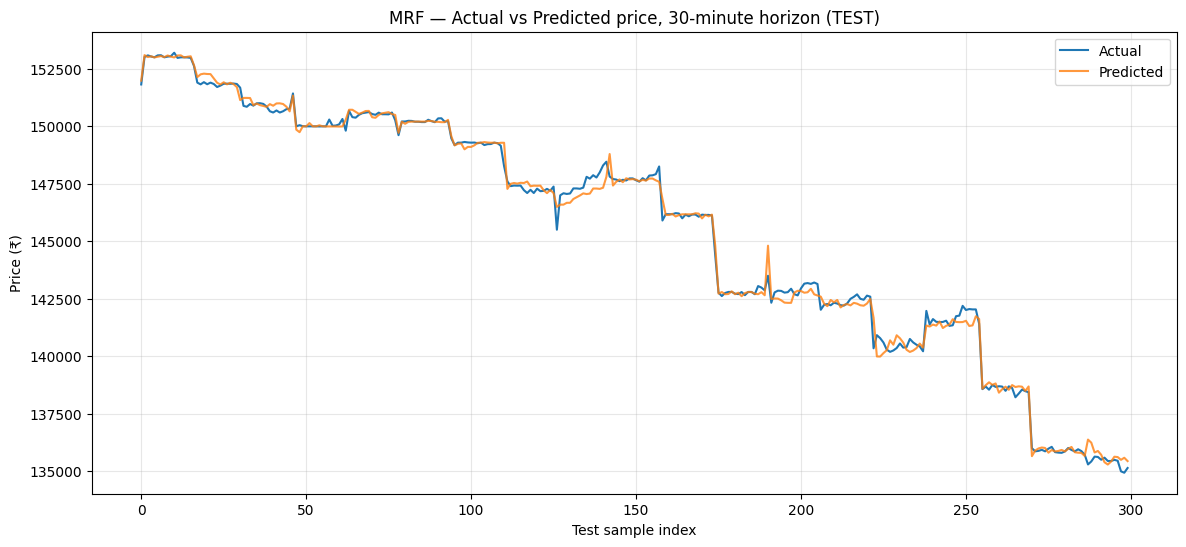

In [92]:
# CELL 36 — Actual vs predicted price (test set, chosen horizon)
PLOT_HORIZON = 30
h_idx = list(HORIZONS.keys()).index(PLOT_HORIZON)
chosen = gru_test_pred if BEST_MODEL_PER_HORIZON[PLOT_HORIZON] == "GRU" else xgb_test_pred

actual_price = PRICE_test * np.exp(Y_test[:, h_idx])
pred_price = PRICE_test * np.exp(chosen[:, h_idx])
n_plot = min(300, len(actual_price))

plt.figure(figsize=(14, 6))
plt.plot(actual_price[:n_plot], label="Actual")
plt.plot(pred_price[:n_plot], label="Predicted", alpha=0.8)
plt.title(f"{STOCK_NAME} — Actual vs Predicted price, {PLOT_HORIZON}-minute horizon (TEST)")
plt.xlabel("Test sample index"); plt.ylabel("Price (₹)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [93]:
# CELL 37 — Historical candlestick plot helper
def plot_candles(ax, ohlc_df, start_x=0):
    x_positions = np.arange(start_x, start_x + len(ohlc_df))
    for i, (_, row) in zip(x_positions, ohlc_df.iterrows()):
        o, h, l, c = row["Open"], row["High"], row["Low"], row["Close"]
        color = "green" if c >= o else "red"
        ax.plot([i, i], [l, h], color="black", linewidth=1)
        body_low, body_h = min(o, c), max(abs(c - o), 1e-6)
        ax.add_patch(Rectangle((i - 0.3, body_low), 0.6, body_h, facecolor=color, edgecolor="black"))
    return x_positions

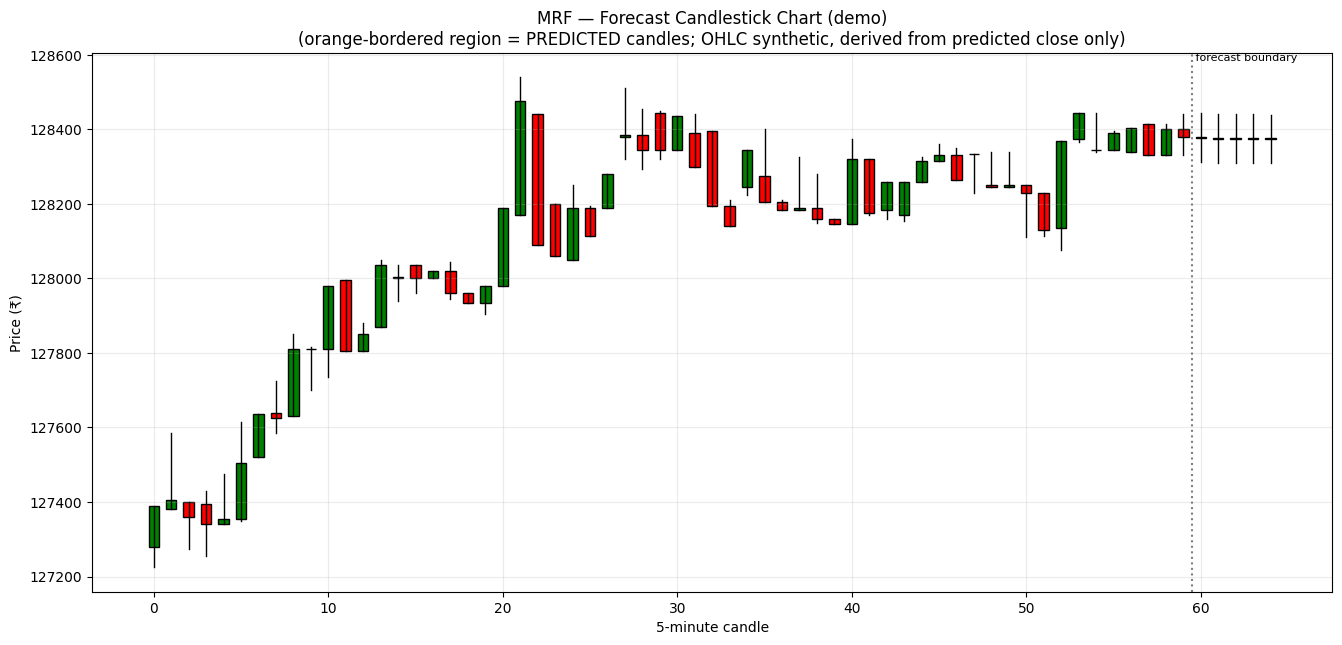

In [94]:
# CELL 38 — Forecast candlestick chart (synthetic OHLC honestly labeled, real historical candles)
def synthesize_forecast_ohlc(current_price, predicted_closes):
    """
    The model predicts CLOSE returns only. We derive conservative synthetic
    OHLC for display: Open = previous predicted close, Close = predicted
    close, High/Low = a small conservative wick around Open/Close scaled by
    the recent realized candle range -- NOT a smooth straight line, and
    explicitly labeled as synthetic everywhere it's shown.
    """
    recent_wick_frac = float(feat_df["UpperPctRange"].tail(200).mean() + feat_df["LowerPctRange"].tail(200).mean())
    closes = [current_price] + list(predicted_closes)
    rows = []
    for i in range(1, len(closes)):
        o, c = closes[i-1], closes[i]
        body = abs(c - o)
        wick = max(body * recent_wick_frac, o * 0.0005)
        rows.append({"Open": o, "Close": c, "High": max(o, c) + wick, "Low": min(o, c) - wick})
    return pd.DataFrame(rows)

def plot_forecast_chart(hist_df, predicted_prices, horizon_minutes, title):
    fig, ax = plt.subplots(figsize=(16, 7))
    hist_recent = hist_df.tail(60).reset_index(drop=True)
    plot_candles(ax, hist_recent, start_x=0)

    forecast_ohlc = synthesize_forecast_ohlc(hist_recent["Close"].iloc[-1], predicted_prices)
    fx = plot_candles(ax, forecast_ohlc, start_x=len(hist_recent))

    ax.axvline(len(hist_recent) - 0.5, linestyle=":", color="gray")
    ax.text(len(hist_recent) - 0.5, ax.get_ylim()[1], " forecast boundary", fontsize=8, va="top")
    ax.set_title(title + "\n(orange-bordered region = PREDICTED candles; OHLC synthetic, derived from predicted close only)")
    ax.set_xlabel("5-minute candle"); ax.set_ylabel("Price (₹)")
    ax.grid(True, alpha=0.25)
    plt.show()
    return forecast_ohlc

demo_current_price = float(model_df["Close"].iloc[-1])
demo_predicted_closes = demo_current_price * np.exp(np.cumsum(gru_test_pred[-1, :5] - np.concatenate([[0], gru_test_pred[-1, :4]])))
# simpler: just show cumulative predicted path for the first 5 output steps of the last test sample
demo_predicted_closes = demo_current_price * np.exp(gru_test_pred[-1, :5])
_ = plot_forecast_chart(model_df.tail(60), demo_predicted_closes, 30, f"{STOCK_NAME} — Forecast Candlestick Chart (demo)")

In [95]:
# CELL 39 — Market status / holiday / session guard
def market_is_open(exchange="NSE"):
    now = pd.Timestamp.now(tz=IST)
    today = now.strftime("%Y-%m-%d")
    status = get_market_status(exchange)
    market_status = status.get("status", "UNKNOWN")
    timings = get_market_timings(today, exchange)

    if timings is None:
        return {"open": False, "reason": "No NSE timing data for today (holiday/weekend/unavailable)",
                "status": market_status, "now": str(now), "session_start": None, "session_end": None}

    start = pd.to_datetime(timings["start_time"], unit="ms", utc=True).tz_convert(IST)
    end = pd.to_datetime(timings["end_time"], unit="ms", utc=True).tz_convert(IST)
    open_now = (market_status == "NORMAL_OPEN") and (start <= now < end)

    return {"open": bool(open_now), "status": market_status, "now": str(now),
            "session_start": str(start), "session_end": str(end)}

market_info = market_is_open()
print(json.dumps(market_info, indent=2))

{
  "open": true,
  "status": "NORMAL_OPEN",
  "now": "2026-09-15 14:34:40.021303+05:30",
  "session_start": "2026-09-15 09:15:00+05:30",
  "session_end": "2026-09-15 15:30:00+05:30"
}


In [96]:
# ============================================================
# CELL 40 — LIVE HISTORY WITH PROPER FEATURE WARM-UP
# ============================================================

# IMPORTANT:
# We need considerably more historical candles than LOOKBACK.
# LOOKBACK = 48, but several indicators use 50-100+ observations.
#
# We therefore fetch several recent trading days and then remove
# incomplete candles.
#
# We NEVER mix future candles and NEVER use the currently forming candle.

LIVE_WARMUP_DAYS = 7

def get_live_warmup_data(instrument_key, interval=5, warmup_days=LIVE_WARMUP_DAYS):
    """
    Fetch enough recent historical data to warm up all rolling indicators.

    We intentionally fetch several trading days rather than only today's
    intraday candles.

    The latest incomplete candle is removed.
    """

    now = pd.Timestamp.now(tz=IST)

    start_date = (now - pd.Timedelta(days=warmup_days)).strftime("%Y-%m-%d")
    end_date = now.strftime("%Y-%m-%d")

    print("Fetching live warm-up history...")
    print("Start:", start_date)
    print("End  :", end_date)

    recent = download_history(
        instrument_key,
        start_date,
        end_date,
        interval=interval
    )

    if recent.empty:
        raise RuntimeError("No live warm-up data returned from Upstox.")

    recent, report = validate_and_clean(recent)

    # Restrict to NSE normal equity session
    recent = restrict_to_normal_session(recent)

    # Remove any currently-forming candle
    candle_end = recent["Datetime"] + pd.Timedelta(minutes=interval)

    if recent["Datetime"].dt.tz is None:
        now_compare = now.tz_localize(None)
    else:
        now_compare = now

    recent = recent.loc[candle_end <= now_compare].copy()

    recent = (
        recent
        .drop_duplicates(subset=["Datetime"])
        .sort_values("Datetime")
        .reset_index(drop=True)
    )

    print("\nLIVE WARM-UP DATA")
    print("Rows:", len(recent))
    print("Date range:", recent["Datetime"].min(), "->", recent["Datetime"].max())
    print("Sessions:", recent["Datetime"].dt.date.nunique())

    if len(recent):
        print("Latest completed candle:")
        print(recent.iloc[-1]["Datetime"])

    return recent


completed_live = get_live_warmup_data(
    INSTRUMENT_KEY,
    interval=BASE_TIMEFRAME_MINUTES
)

display(completed_live.tail(10))

Fetching live warm-up history...
Start: 2026-09-08
End  : 2026-09-15
Requesting 1 monthly chunks for NSE_EQ|INE883A01011 ...
  [1/1] 2026-09-08 -> 2026-09-15: 300 rows

LIVE WARM-UP DATA
Rows: 300
Date range: 2026-09-08 09:15:00+05:30 -> 2026-09-11 15:25:00+05:30
Sessions: 4
Latest completed candle:
2026-09-11 15:25:00+05:30


,Datetime,Open,High,Low,Close,Volume,OpenInterest
290,2026-09-11 14:40:00+05:30,128375.0,128400.0,128350.0,128370.0,14,0
291,2026-09-11 14:45:00+05:30,128370.0,128370.0,128250.0,128305.0,20,0
292,2026-09-11 14:50:00+05:30,128250.0,128325.0,128210.0,128280.0,59,0
293,2026-09-11 14:55:00+05:30,128200.0,128280.0,128200.0,128280.0,23,0
294,2026-09-11 15:00:00+05:30,128300.0,128310.0,127900.0,128200.0,143,0
295,2026-09-11 15:05:00+05:30,128200.0,128250.0,128130.0,128235.0,61,0
296,2026-09-11 15:10:00+05:30,128130.0,128320.0,128130.0,128310.0,64,0
297,2026-09-11 15:15:00+05:30,128310.0,128310.0,128110.0,128215.0,47,0
298,2026-09-11 15:20:00+05:30,128215.0,128395.0,128215.0,128395.0,78,0
299,2026-09-11 15:25:00+05:30,128390.0,128765.0,128375.0,128760.0,138,0


In [97]:
# ============================================================
# CELL 41 — PRODUCTION LIVE FEATURE PIPELINE
# ============================================================

def build_live_features(recent_ohlcv_df, include_market_context=True):
    """
    Build the exact same feature structure used during training.

    IMPORTANT:
    - Uses only completed historical candles
    - No future information
    - Same feature functions as training
    - Proper rolling warm-up
    - Includes market context when available
    """

    x = (
        recent_ohlcv_df
        .copy()
        .sort_values("Datetime")
        .drop_duplicates("Datetime")
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Candle anatomy
    # --------------------------------------------------------
    x = add_candle_anatomy(x)

    # --------------------------------------------------------
    # Technical indicators
    # --------------------------------------------------------
    x = add_technical_indicators(x)

    # --------------------------------------------------------
    # Candlestick patterns
    # --------------------------------------------------------
    x, _ = add_patterns(x)

    # --------------------------------------------------------
    # Pattern + context interactions
    # --------------------------------------------------------
    trend_up_live = (
        x["EMA_10_dist"] > 0
    ).astype(np.float32)

    for col in PATTERN_COLUMNS:
        x[col + "_x_trend"] = (
            x[col] * (2 * trend_up_live - 1)
        )

    pat_sum = x[PATTERN_COLUMNS].sum(axis=1)

    rolling_vol_median = (
        x["Volatility_24"]
        .rolling(100, min_periods=50)
        .median()
    )

    high_vol = (
        x["Volatility_24"] > rolling_vol_median
    ).astype(np.float32)

    high_rel_vol = (
        x["RelativeVolume"] > 1.2
    ).astype(np.float32)

    x["ANY_PATTERN_HIGH_VOL"] = (
        (pat_sum > 0).astype(np.float32) * high_vol
    )

    x["ANY_PATTERN_HIGH_RELVOL"] = (
        (pat_sum > 0).astype(np.float32) * high_rel_vol
    )

    # --------------------------------------------------------
    # NIFTY context
    # --------------------------------------------------------
    if include_market_context:

        try:
            now = pd.Timestamp.now(tz=IST)

            context_start = (
                now - pd.Timedelta(days=7)
            ).strftime("%Y-%m-%d")

            context_end = now.strftime("%Y-%m-%d")

            idx_raw = download_history(
                NSE_INDEX_INSTRUMENT_KEY,
                context_start,
                context_end,
                interval=BASE_TIMEFRAME_MINUTES
            )

            if not idx_raw.empty:

                idx_raw, _ = validate_and_clean(idx_raw)

                idx_raw = restrict_to_normal_session(idx_raw)

                idx_raw = (
                    idx_raw[
                        ["Datetime", "Close"]
                    ]
                    .rename(
                        columns={"Close": "Index_Close"}
                    )
                    .sort_values("Datetime")
                )

                idx_raw["Index_Return_1"] = (
                    idx_raw["Index_Close"].pct_change()
                )

                idx_raw["Index_Volatility_12"] = (
                    idx_raw["Index_Return_1"]
                    .rolling(12, min_periods=12)
                    .std()
                )

                x = x.merge(
                    idx_raw[
                        [
                            "Datetime",
                            "Index_Return_1",
                            "Index_Volatility_12"
                        ]
                    ],
                    on="Datetime",
                    how="left"
                )

                # Forward-fill only MARKET CONTEXT.
                # We do NOT fabricate stock OHLC.
                x["Index_Return_1"] = (
                    x["Index_Return_1"]
                    .ffill()
                    .fillna(0.0)
                )

                x["Index_Volatility_12"] = (
                    x["Index_Volatility_12"]
                    .ffill()
                    .fillna(0.0)
                )

                print("NIFTY live context merged successfully.")

            else:
                raise RuntimeError("No NIFTY context data.")

        except Exception as ex:

            print(
                "WARNING: NIFTY context unavailable:",
                ex
            )

            # Graceful fallback
            x["Index_Return_1"] = 0.0
            x["Index_Volatility_12"] = 0.0

    else:

        x["Index_Return_1"] = 0.0
        x["Index_Volatility_12"] = 0.0

    # --------------------------------------------------------
    # Clean numerical values
    # --------------------------------------------------------
    x = x.replace(
        [np.inf, -np.inf],
        np.nan
    )

    return x


print("Production live feature pipeline defined.")

Production live feature pipeline defined.


In [98]:
# ============================================================
# CELL 41A — LIVE VS TRAINING FEATURE DISTRIBUTION AUDIT
# ============================================================

def audit_live_feature_distribution(live_feat, feature_columns, scaler):
    """
    Detects whether live features are wildly outside the training
    distribution used by the StandardScaler.
    """

    rows = []

    latest = live_feat[feature_columns].iloc[-1].astype(float)

    for i, col in enumerate(feature_columns):

        value = latest[col]
        mean = scaler.mean_[i]
        std = scaler.scale_[i]

        z = (value - mean) / (std + 1e-12)

        rows.append({
            "Feature": col,
            "Live_Value": value,
            "Train_Mean": mean,
            "Train_Std": std,
            "Z_Score": z,
            "Abs_Z": abs(z)
        })

    audit = pd.DataFrame(rows).sort_values(
        "Abs_Z",
        ascending=False
    ).reset_index(drop=True)

    print("=" * 70)
    print("LIVE FEATURE DISTRIBUTION AUDIT")
    print("=" * 70)

    print(
        "Features with |Z| > 5:",
        int((audit["Abs_Z"] > 5).sum())
    )

    print(
        "Features with |Z| > 10:",
        int((audit["Abs_Z"] > 10).sum())
    )

    display(audit.head(20))

    return audit


print("Feature audit function defined.")

Feature audit function defined.


In [99]:
# ============================================================
# CELL 42 — VALIDATION-BASED CONFIDENCE ENGINE
# ============================================================

def build_validation_confidence_stats(
    y_true,
    gru_pred,
    xgb_pred,
    horizons
):
    """
    Calculate confidence calibration statistics using VALIDATION ONLY.

    These statistics must NOT use TEST data.
    """

    stats = {}

    for j, minutes in enumerate(horizons.keys()):

        actual = y_true[:, j]
        gru = gru_pred[:, j]
        xgb = xgb_pred[:, j]

        actual_dir = (actual > 0).astype(int)
        gru_dir = (gru > 0).astype(int)

        acc = accuracy_score(
            actual_dir,
            gru_dir
        )

        agreement = (
            np.sign(gru) == np.sign(xgb)
        ).astype(float)

        abs_pred = np.abs(gru)

        stats[minutes] = {
            "accuracy": float(acc),
            "agreement_rate": float(agreement.mean()),
            "p50_abs_return": float(np.percentile(abs_pred, 50)),
            "p75_abs_return": float(np.percentile(abs_pred, 75)),
            "p90_abs_return": float(np.percentile(abs_pred, 90)),
            "p95_abs_return": float(np.percentile(abs_pred, 95)),
        }

    return stats


VALIDATION_CONFIDENCE_STATS = build_validation_confidence_stats(
    Y_val,
    gru_val_pred,
    xgb_val_pred,
    HORIZONS
)


def compute_confidence(
    horizon_minutes,
    gru_pred_return,
    xgb_pred_return
):
    """
    Confidence score is a ranking score, NOT probability of profit.

    Components:
    1. Validation directional accuracy
    2. GRU/XGB agreement
    3. Prediction conviction relative to validation distribution
    """

    stats = VALIDATION_CONFIDENCE_STATS[horizon_minutes]

    base_accuracy = stats["accuracy"]

    agreement = (
        1.0
        if np.sign(gru_pred_return) ==
           np.sign(xgb_pred_return)
        else 0.0
    )

    p50 = stats["p50_abs_return"]
    p90 = stats["p90_abs_return"]

    abs_return = abs(gru_pred_return)

    if abs_return <= p50:
        conviction = 0.35 * (
            abs_return / (p50 + 1e-9)
        )
    else:
        conviction = 0.35 + 0.65 * np.clip(
            (abs_return - p50) /
            (p90 - p50 + 1e-9),
            0,
            1
        )

    score = (
        0.50 * base_accuracy +
        0.25 * agreement +
        0.25 * conviction
    )

    return float(
        np.clip(score * 100, 0, 100)
    )


print("Validation-based confidence engine ready.")

Validation-based confidence engine ready.


In [100]:
# CELL 43 — Target / stop-loss / risk-reward (separate from the training label)
def compute_risk_levels(current_price, predicted_price, recent_atr):
    """
    ATR-based risk management. This is a DECISION/DISPLAY rule, not a training
    label -- the model was never trained to hit these levels (spec section 29).
    """
    direction = 1 if predicted_price >= current_price else -1
    stop_distance = max(recent_atr * 1.0, current_price * 0.0015)
    target_price = predicted_price
    stop_loss = current_price - direction * stop_distance

    reward = abs(target_price - current_price)
    risk = abs(current_price - stop_loss)
    rr = reward / risk if risk > 0 else np.nan

    return {
        "target_price": round(float(target_price), 2),
        "stop_loss": round(float(stop_loss), 2),
        "risk_reward": round(float(rr), 2) if np.isfinite(rr) else None,
    }

print("Risk/target/stop-loss function defined (ATR-based, illustrative -- see disclaimer in Cell 45).")

Risk/target/stop-loss function defined (ATR-based, illustrative -- see disclaimer in Cell 45).


In [101]:
# ============================================================
# CELL 44 — NEXT FIVE PREDICTED CANDLES
# ============================================================

def generate_next_five_candles(
    model,
    scaled_window,
    current_price,
    last_time,
    recent_wick_frac,
    max_single_step_pct=0.02
):
    """
    Generate the next five 5-minute forecast candles.

    The model predicts cumulative returns at:
    5, 10, 15, 20, 25 minutes.

    OHLC is synthetic because the model directly predicts returns/close,
    not independent OHLC values.
    """

    pred = model.predict(
        scaled_window[np.newaxis, ...],
        verbose=0
    )[0]

    requested_horizons = [
        5, 10, 15, 20, 25
    ]

    horizon_indices = [
        list(HORIZONS.keys()).index(m)
        for m in requested_horizons
    ]

    cumulative_returns = pred[horizon_indices]

    # --------------------------------------------------------
    # Sanity audit
    # --------------------------------------------------------
    print("RAW 5-CANDLE PREDICTED RETURNS")

    for m, r in zip(
        requested_horizons,
        cumulative_returns
    ):
        print(
            f"{m:>2}m : "
            f"{r*100:+.4f}%"
        )

    # Convert cumulative log-return → price
    prices = (
        current_price *
        np.exp(cumulative_returns)
    )

    # --------------------------------------------------------
    # Generate synthetic OHLC
    # --------------------------------------------------------
    candles = []

    prev_close = float(current_price)

    t = pd.Timestamp(last_time)

    wick_frac = float(
        np.clip(
            recent_wick_frac,
            0.001,
            0.05
        )
    )

    for price in prices:

        price = float(price)

        step_return = (
            price / prev_close - 1
        )

        # Safety diagnostic only.
        # We DO NOT silently clip the model prediction.
        if abs(step_return) > max_single_step_pct:

            print(
                "WARNING: unusually large predicted "
                f"5-minute move: {step_return*100:.2f}%"
            )

        t = (
            t +
            pd.Timedelta(minutes=5)
        )

        body = abs(
            price - prev_close
        )

        wick = max(
            body * wick_frac,
            prev_close * 0.0005
        )

        candle = {
            "time": t.strftime("%H:%M"),
            "open": round(prev_close, 2),
            "high": round(
                max(prev_close, price) + wick,
                2
            ),
            "low": round(
                min(prev_close, price) - wick,
                2
            ),
            "close": round(price, 2),
            "type": "predicted",
            "ohlc_note":
                "Synthetic forecast OHLC derived from predicted close."
        }

        candles.append(candle)

        prev_close = price

    return candles


print("Five-candle forecast generator updated.")

Five-candle forecast generator updated.


In [102]:
# ============================================================
# CELL 45 — PRODUCTION predict_stock()
# ============================================================

def predict_stock(
    instrument_key,
    timeframe_minutes,
    stock_name=STOCK_NAME
):

    assert (
        timeframe_minutes in HORIZONS
    ), (
        f"timeframe_minutes must be one of "
        f"{list(HORIZONS.keys())}"
    )

    # ========================================================
    # 1. MARKET GUARD
    # ========================================================

    market_info = market_is_open()

    if not market_info["open"]:

        return {
            "stock": stock_name,
            "instrument_key": instrument_key,
            "market_status": market_info["status"],
            "message": "MARKET CLOSED",
            "reason": market_info.get(
                "reason",
                "NSE session is closed."
            ),
            "now": market_info["now"]
        }

    # ========================================================
    # 2. GET WARMED-UP LIVE DATA
    # ========================================================

    completed = get_live_warmup_data(
        instrument_key,
        interval=BASE_TIMEFRAME_MINUTES,
        warmup_days=LIVE_WARMUP_DAYS
    )

    if completed.empty:

        return {
            "stock": stock_name,
            "market_status":
                market_info["status"],
            "message":
                "NO_MARKET_DATA"
        }

    # ========================================================
    # 3. FEATURE ENGINE
    # ========================================================

    live_feat = build_live_features(
        completed,
        include_market_context=True
    )

    # Remove rows that cannot support all indicators
    live_feat = live_feat.dropna(
        subset=FEATURE_COLUMNS
    ).reset_index(drop=True)

    if len(live_feat) < LOOKBACK:

        return {
            "stock": stock_name,
            "market_status":
                market_info["status"],
            "message":
                "INSUFFICIENT_WARMED_DATA",
            "rows_available":
                len(live_feat),
            "rows_required":
                LOOKBACK
        }

    # ========================================================
    # 4. FEATURE DISTRIBUTION AUDIT
    # ========================================================

    live_audit = audit_live_feature_distribution(
        live_feat,
        FEATURE_COLUMNS,
        scaler
    )

    extreme_count = int(
        (live_audit["Abs_Z"] > 10).sum()
    )

    if extreme_count > 0:

        return {
            "stock": stock_name,
            "market_status":
                market_info["status"],
            "message":
                "MODEL_INPUT_OUT_OF_DISTRIBUTION",
            "reason":
                f"{extreme_count} features have "
                "|Z| > 10 versus training distribution.",
            "top_extreme_features":
                live_audit.head(10)[
                    [
                        "Feature",
                        "Live_Value",
                        "Z_Score"
                    ]
                ].to_dict("records")
        }

    # ========================================================
    # 5. BUILD LATEST SEQUENCE
    # ========================================================

    window_raw = (
        live_feat[
            FEATURE_COLUMNS
        ]
        .values[-LOOKBACK:]
        .astype(np.float32)
    )

    window_scaled = (
        scaler
        .transform(window_raw)
        .astype(np.float32)
    )

    # ========================================================
    # 6. CURRENT PRICE / TIME
    # ========================================================

    current_price = float(
        live_feat["Close"].iloc[-1]
    )

    latest_candle_time = (
        live_feat["Datetime"].iloc[-1]
    )

    # ========================================================
    # 7. MODEL PREDICTION
    # ========================================================

    gru_vector = gru_model.predict(
        window_scaled[np.newaxis, ...],
        verbose=0
    )[0]

    h_idx = list(
        HORIZONS.keys()
    ).index(timeframe_minutes)

    gru_return = float(
        gru_vector[h_idx]
    )

    # XGBoost
    xgb_return = float(
        xgb_models[
            timeframe_minutes
        ].predict(
            flatten_for_xgb(
                window_scaled[np.newaxis, ...]
            )
        )[0]
    )

    # ========================================================
    # 8. PREDICTED PRICE
    # ========================================================

    predicted_price = (
        current_price *
        math.exp(gru_return)
    )

    expected_move_rupees = (
        predicted_price -
        current_price
    )

    expected_move_percent = (
        predicted_price /
        current_price -
        1
    ) * 100

    # ========================================================
    # 9. DIRECTION
    # ========================================================

    if gru_return > 0:
        direction = "INCREASE"
    elif gru_return < 0:
        direction = "DECREASE"
    else:
        direction = "SIDEWAYS"

    # ========================================================
    # 10. CONFIDENCE
    # ========================================================

    confidence = compute_confidence(
        timeframe_minutes,
        gru_return,
        xgb_return
    )

    # ========================================================
    # 11. FIVE-CANDLE FORECAST
    # ========================================================

    forecast_candles = []

    if timeframe_minutes == 5:

        recent_wick_frac = float(
            (
                live_feat[
                    "UpperPctRange"
                ].tail(200).mean()
                +
                live_feat[
                    "LowerPctRange"
                ].tail(200).mean()
            )
        )

        forecast_candles = (
            generate_next_five_candles(
                gru_model,
                window_scaled,
                current_price,
                latest_candle_time,
                recent_wick_frac
            )
        )

        # Final 25-minute price
        if forecast_candles:

            predicted_price = float(
                forecast_candles[-1]["close"]
            )

            expected_move_rupees = (
                predicted_price -
                current_price
            )

            expected_move_percent = (
                predicted_price /
                current_price -
                1
            ) * 100

    # ========================================================
    # 12. RISK MANAGEMENT
    # ========================================================

    atr_now = float(
        live_feat["ATR_pct"].iloc[-1]
        * current_price
    )

    risk_levels = compute_risk_levels(
        current_price,
        predicted_price,
        atr_now
    )

    # ========================================================
    # 13. SIGNAL FILTER
    # ========================================================

    MIN_CONFIDENCE = 60.0

    if (
        confidence < MIN_CONFIDENCE
        or direction == "SIDEWAYS"
    ):

        signal = "NO TRADE"

    else:

        signal = (
            "BULLISH"
            if direction == "INCREASE"
            else "BEARISH"
        )

    # ========================================================
    # 14. FINAL RESULT
    # ========================================================

    return {

        "stock": stock_name,

        "instrument_key":
            instrument_key,

        "market_status":
            market_info["status"],

        "current_price":
            round(current_price, 2),

        "latest_completed_candle":
            str(latest_candle_time),

        "timeframe_minutes":
            timeframe_minutes,

        "direction":
            direction,

        "predicted_price":
            round(
                float(predicted_price),
                2
            ),

        "expected_move_rupees":
            round(
                float(expected_move_rupees),
                2
            ),

        "expected_move_percent":
            round(
                float(expected_move_percent),
                3
            ),

        "confidence":
            round(
                float(confidence),
                1
            ),

        "signal":
            signal,

        "xgb_predicted_return":
            round(
                xgb_return,
                6
            ),

        "gru_predicted_return":
            round(
                gru_return,
                6
            ),

        "target_price":
            risk_levels[
                "target_price"
            ],

        "stop_loss":
            risk_levels[
                "stop_loss"
            ],

        "risk_reward":
            risk_levels[
                "risk_reward"
            ],

        "forecast_candles":
            forecast_candles,

        "disclaimer":
            "AI forecast and illustrative risk levels only. "
            "Not guaranteed financial advice."
    }


print("Production prediction engine updated.")

Production prediction engine updated.


In [103]:
# ============================================================
# CELL 45B — SREE.AI FORMATTED REPORTING ENGINE
# ============================================================
import pytz

def print_sree_forecast_report(instrument_key, min_expected_move_pct=0.10):
    """
    Core execution and reporting engine for SREE.AI.
    Enforces strict time validation, session safety limits, stale-data checks,
    and prints the exact formatted console layouts requested by the client.
    """
    # Configurable trade signals
    MIN_CONFIDENCE = 60.0

    # 1. Fetch live market state and check connection
    market_info = market_is_open()

    # 2. Retrieve live candle feed
    try:
        completed = get_live_warmup_data(instrument_key, interval=BASE_TIMEFRAME_MINUTES, warmup_days=LIVE_WARMUP_DAYS)
    except Exception as e:
        completed = pd.DataFrame()

    if completed.empty:
        print("━━━━━━━━━━━━━━━━━━━━━━━━━━")
        print("        SREE.AI")
        print("━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
        print("🔴 NO MARKET DATA RETURNED FROM UPSTOX\n")
        print("Please verify your credentials and connection.")
        return

    # 3. Data Freshness and Age Diagnostics
    now_ist = pd.Timestamp.now(tz=pytz.timezone(IST))
    latest_candle_time = completed["Datetime"].iloc[-1]

    # Convert timestamps to timezone-aware for fair comparison
    if latest_candle_time.tzinfo is None:
        latest_candle_time = latest_candle_time.tz_localize(IST)
    else:
        latest_candle_time = latest_candle_time.tz_convert(IST)

    data_age_minutes = (now_ist - latest_candle_time).total_seconds() / 60.0

    # Flag data as stale if the gap is greater than 3 intervals (15 mins) during market hours
    is_stale = (data_age_minutes > 15.0) and (market_info["open"])

    # 4. Handle CLOSED MARKET State
    if not market_info["open"] or is_stale:
        print("━━━━━━━━━━━━━━━━━━━━━━━━━━")
        print("        SREE.AI")
        print("━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
        print(STOCK_NAME)
        print("\nMarket Status:")
        if is_stale:
            print("⚠️  STALE MARKET DATA")
            print(f"Requested Latest Date: {now_ist.strftime('%Y-%m-%d %H:%M %Z')}")
            print(f"Actual Latest Candle:  {latest_candle_time.strftime('%Y-%m-%d %H:%M %Z')}")
            print(f"Data Delay/Age:        {data_age_minutes:.1f} minutes")
        else:
            print("🔴 MARKET CLOSED")
            print(f"Last Completed Candle: {latest_candle_time.strftime('%I:%M %p')}")

        print(f"Last Price:            ₹{completed['Close'].iloc[-1]:.2f}\n")
        print("Forecast:")
        print("Unavailable because the NSE")
        print("market is currently closed or")
        print("the live feed has stopped reporting.\n")
        print("Reason:")
        print("SREE.AI only generates live")
        print("intraday forecasts from valid")
        print("completed market candles.")
        return

    # 5. Live Feature Pipeline and Inference Inputs
    live_feat = build_live_features(completed, include_market_context=True)
    live_feat = live_feat.dropna(subset=FEATURE_COLUMNS).reset_index(drop=True)

    if len(live_feat) < LOOKBACK:
        print(f"Warm-up warning: Indicator features are warming up ({len(live_feat)}/{LOOKBACK} rows)")
        return

    current_price = float(live_feat["Close"].iloc[-1])
    origin_time = live_feat["Datetime"].iloc[-1]
    if origin_time.tzinfo is not None:
         origin_time = origin_time.tz_convert(IST)

    # Execute OOD distribution audit
    live_audit = audit_live_feature_distribution(live_feat, FEATURE_COLUMNS, scaler)
    extreme_count = int((live_audit["Abs_Z"] > 10.0).sum())

    # Prepare Sequence Window
    window_raw = live_feat[FEATURE_COLUMNS].values[-LOOKBACK:].astype(np.float32)
    window_scaled = scaler.transform(window_raw).astype(np.float32)

    # Generate Predictions for all horizons
    gru_vector = gru_model.predict(window_scaled[np.newaxis, ...], verbose=0)[0]

    print("━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print("        SREE.AI")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
    print(STOCK_NAME)
    print(f"Current Price: ₹{current_price:.2f}")
    print(f"Current/Last Completed Candle: {origin_time.strftime('%I:%M %p')}\n")
    print("FORECAST")
    print("──────────────────────────\n")

    forecasts = []
    session_safe_counts = 0

    # Strictly track 5, 10, 20, 30, 45, 60 min horizons
    target_intervals = [5, 10, 20, 30, 45, 60]

    for mins in target_intervals:
        step_offset = HORIZONS[mins] if mins in HORIZONS else int(mins / 5)
        target_time = origin_time + pd.Timedelta(minutes=mins)

        # Define strict NSE intraday limits (09:15 to 15:30)
        session_close_time = origin_time.replace(hour=15, minute=30, second=0, microsecond=0)

        print(f"{mins} MIN FROM NOW")
        print(f"Time: {target_time.strftime('%I:%M %p')}")

        if target_time > session_close_time:
            print("Predicted Price: MARKET CLOSED / INSUFFICIENT SESSION HORIZON")
            print("──────────────────────────\n")
            continue

        # Retrieve model output index safely
        h_idx = list(HORIZONS.keys()).index(mins) if mins in HORIZONS else 0
        model_used = BEST_MODEL_PER_HORIZON.get(mins, "GRU")

        if model_used == "GRU":
            predicted_return = float(gru_vector[h_idx])
        else:
            # XGBoost fallback prediction
            flat_feat = flatten_for_xgb(window_scaled[np.newaxis, ...])
            predicted_return = float(xgb_models[mins].predict(flat_feat)[0])

        predicted_price = current_price * np.exp(predicted_return)
        expected_move = predicted_price - current_price
        expected_change = (expected_move / current_price) * 100.0

        direction = "FLAT"
        if predicted_price > current_price:
            direction = "UP"
        elif predicted_price < current_price:
            direction = "DOWN"

        # Compute prediction confidence using validation statistics
        xgb_ret_comp = float(xgb_models[mins].predict(flatten_for_xgb(window_scaled[np.newaxis, ...]))[0]) if mins in xgb_models else predicted_return
        confidence_score = compute_confidence(mins, predicted_return, xgb_ret_comp)

        print(f"Predicted Price: ₹{predicted_price:.2f}")
        print(f"Expected Move: {expected_move:+.2f}")
        print(f"Expected Change: {expected_change:+.2f}%")
        print(f"Direction: {direction}")
        print(f"Confidence: {confidence_score:.1f} / 100")
        print("──────────────────────────\n")

        forecasts.append({
            "minutes": mins,
            "change_pct": expected_change,
            "confidence": confidence_score,
            "direction": direction
        })
        session_safe_counts += 1

    # 6. Overall Decision Signal
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print("OVERALL SIGNAL")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━\n")

    # Decision criteria based on the 30-minute target horizon
    eval_horizon = 30
    eval_item = next((f for f in forecasts if f["minutes"] == eval_horizon), None)

    if eval_item is None or len(forecasts) == 0:
        print("Signal:")
        print("⚠️  NO TRADE\n")
        print("Reason:")
        print("Market session limits exceeded.")
    elif abs(eval_item["change_pct"]) < min_expected_move_pct:
        print("Signal:")
        print("⚠️  NO TRADE\n")
        print("Reason:")
        print(f"Predicted movement ({abs(eval_item['change_pct']):.2f}%) is too small")
        print(f"to justify a trade (threshold: {min_expected_move_pct:.2f}%).")
    elif eval_item["confidence"] < MIN_CONFIDENCE:
        print("Signal:")
        print("⚠️  NO TRADE\n")
        print("Reason:")
        print(f"Confidence ({eval_item['confidence']:.1f}/100) is below")
        print(f"minimum required standard ({MIN_CONFIDENCE:.1f}/100).")
    else:
        trade_direction = "🟢 BUY" if eval_item["direction"] == "UP" else "🔴 SELL"
        print("Signal:")
        print(f"{trade_direction}\n")
        print("Reason:")
        print(f"Validation expectations met with {eval_item['confidence']:.1f} confidence")
        print(f"at a predicted {eval_item['change_pct']:.2f}% shift.")
    print("\n──────────────────────────")


In [104]:
# ============================================================
# CELL 46 — PRODUCTION INFERENCE TEST
# ============================================================

demo_result = predict_stock(
    INSTRUMENT_KEY,
    5,
    STOCK_NAME
)

print(
    json.dumps(
        demo_result,
        indent=2,
        default=str
    )
)

Fetching live warm-up history...
Start: 2026-09-08
End  : 2026-09-15
Requesting 1 monthly chunks for NSE_EQ|INE883A01011 ...
  [1/1] 2026-09-08 -> 2026-09-15: 300 rows

LIVE WARM-UP DATA
Rows: 300
Date range: 2026-09-08 09:15:00+05:30 -> 2026-09-11 15:25:00+05:30
Sessions: 4
Latest completed candle:
2026-09-11 15:25:00+05:30
Requesting 1 monthly chunks for NSE_INDEX|Nifty 50 ...
  [1/1] 2026-09-08 -> 2026-09-15: 300 rows
NIFTY live context merged successfully.
LIVE FEATURE DISTRIBUTION AUDIT
Features with |Z| > 5: 0
Features with |Z| > 10: 0


,Feature,Live_Value,Train_Mean,Train_Std,Z_Score,Abs_Z
0,PATTERN_three_outside_up_x_trend,1.000000,3.258841e-02,0.205147,4.715708,4.715708
1,PATTERN_three_outside_up,1.000000,4.314715e-02,0.203188,4.709193,4.709193
2,RelativeVolume,4.039024,8.164986e-01,0.912941,3.529831,3.529831
3,PATTERN_marubozu_bull_x_trend,1.000000,4.218815e-02,0.276046,3.469753,3.469753
4,PATTERN_marubozu_bull,1.000000,7.798131e-02,0.268142,3.438544,3.438544
5,BB_position,1.371686,4.937675e-01,0.301700,2.909909,2.909909
6,Body,370.000000,-9.833083e-01,152.255001,2.436592,2.436592
7,CosTime,0.996493,-3.560009e-01,0.583731,2.316983,2.316983
8,BodyAbs,370.000000,9.401899e+01,119.762190,2.304409,2.304409
9,ANY_PATTERN_HIGH_RELVOL,1.000000,1.772335e-01,0.381866,2.154594,2.154594


RAW 5-CANDLE PREDICTED RETURNS
 5m : -0.0032%
10m : -0.0051%
15m : -0.0016%
20m : -0.0038%
25m : -0.0034%
{
  "stock": "MRF",
  "instrument_key": "NSE_EQ|INE883A01011",
  "market_status": "NORMAL_OPEN",
  "current_price": 128760.0,
  "latest_completed_candle": "2026-09-11 15:25:00+05:30",
  "timeframe_minutes": 5,
  "direction": "DECREASE",
  "predicted_price": 128755.63,
  "expected_move_rupees": -4.37,
  "expected_move_percent": -0.003,
  "confidence": 35.2,
  "signal": "NO TRADE",
  "xgb_predicted_return": 6e-06,
  "gru_predicted_return": -3.2e-05,
  "target_price": 128755.63,
  "stop_loss": 128953.14,
  "risk_reward": 0.02,
  "forecast_candles": [
    {
      "time": "15:30",
      "open": 128760.0,
      "high": 128824.38,
      "low": 128691.49,
      "close": 128755.87,
      "type": "predicted",
      "ohlc_note": "Synthetic forecast OHLC derived from predicted close."
    },
    {
      "time": "15:35",
      "open": 128755.87,
      "high": 128820.25,
      "low": 128689.06,


In [105]:
# CELL 47 — Save model artifacts
MODEL_DIR = "production_artifacts"
os.makedirs(MODEL_DIR, exist_ok=True)

gru_model.save(os.path.join(MODEL_DIR, "model.keras"))

with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

for m, mdl in xgb_models.items():
    mdl.save_model(os.path.join(MODEL_DIR, f"xgb_{m}m.json"))

with open(os.path.join(MODEL_DIR, "feature_columns.json"), "w") as f:
    json.dump(FEATURE_COLUMNS, f, indent=2)

with open(os.path.join(MODEL_DIR, "pattern_columns.json"), "w") as f:
    json.dump(PATTERN_COLUMNS, f, indent=2)

config = {
    "stock_name": STOCK_NAME,
    "instrument_key": INSTRUMENT_KEY,
    "lookback": LOOKBACK,
    "horizons_minutes": list(HORIZONS.keys()),
    "base_timeframe_minutes": BASE_TIMEFRAME_MINUTES,
    "best_model_per_horizon": BEST_MODEL_PER_HORIZON,
    "live_warmup_days": LIVE_WARMUP_DAYS,
    "confidence_minimum": 60.0,
}
with open(os.path.join(MODEL_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

metadata = {
    "trained_at": str(pd.Timestamp.now(tz=IST)),
    "train_sessions": len(train_sessions),
    "val_sessions": len(val_sessions),
    "test_sessions": len(test_sessions),
    "train_samples": int(train_mask.sum()),
    "val_samples": int(val_mask.sum()),
    "test_samples": int(test_mask.sum()),
}
with open(os.path.join(MODEL_DIR, "model_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

final_test_df.to_csv(os.path.join(MODEL_DIR, "training_metrics.csv"), index=False)

print("Saved artifacts to", MODEL_DIR, ":")
for fn in sorted(os.listdir(MODEL_DIR)):
    print(" -", fn)

Saved artifacts to production_artifacts :
 - config.json
 - feature_columns.json
 - model.keras
 - model_metadata.json
 - pattern_columns.json
 - scaler.pkl
 - training_metrics.csv
 - xgb_10m.json
 - xgb_15m.json
 - xgb_20m.json
 - xgb_25m.json
 - xgb_30m.json
 - xgb_45m.json
 - xgb_5m.json
 - xgb_60m.json


In [106]:
# CELL 48 — Reload artifacts and verify production inference works from disk
loaded_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "model.keras"))
with open(os.path.join(MODEL_DIR, "scaler.pkl"), "rb") as f:
    loaded_scaler = pickle.load(f)
with open(os.path.join(MODEL_DIR, "feature_columns.json")) as f:
    loaded_features = json.load(f)
with open(os.path.join(MODEL_DIR, "config.json")) as f:
    loaded_config = json.load(f)

assert loaded_features == FEATURE_COLUMNS
assert loaded_config["lookback"] == LOOKBACK

sanity_pred = loaded_model.predict(X_test[:1], verbose=0)
print("Reloaded model produces output shape:", sanity_pred.shape)
print("Artifacts reload verified — ready for a MERN backend's Python inference service to load exactly these files.")

Reloaded model produces output shape: (1, 8)
Artifacts reload verified — ready for a MERN backend's Python inference service to load exactly these files.


━━━━━━━━━━━━━━━━━━━━━━━━━━
SREE.AI LIVE SNAPSHOT
━━━━━━━━━━━━━━━━━━━━━━━━━━

MRF

Current Time:
2026-09-15 14:34:42 IST

Latest Completed Candle:
2026-09-15 14:30 IST

Current Price:
₹126500.00

Data Age:
4 minutes

Market Status:
🟢 MARKET OPEN

Requesting 1 monthly chunks for NSE_INDEX|Nifty 50 ...
  [1/1] 2026-09-08 -> 2026-09-15: 300 rows
NIFTY live context merged successfully.


,Horizon,Predicted Price,Expected Return %,Validation Accuracy,Model Used
0,5 min,₹126495.95,-0.003%,52.8%,GRU
1,10 min,₹126493.55,-0.005%,52.5%,GRU
2,15 min,₹126497.94,-0.002%,51.9%,GRU
3,20 min,₹126495.19,-0.004%,51.6%,GRU
4,25 min,₹126495.71,-0.003%,51.0%,GRU
5,30 min,₹126496.10,-0.003%,50.8%,GRU
6,45 min,₹126508.65,+0.007%,49.9%,GRU
7,60 min,₹126507.96,+0.006%,48.0%,GRU


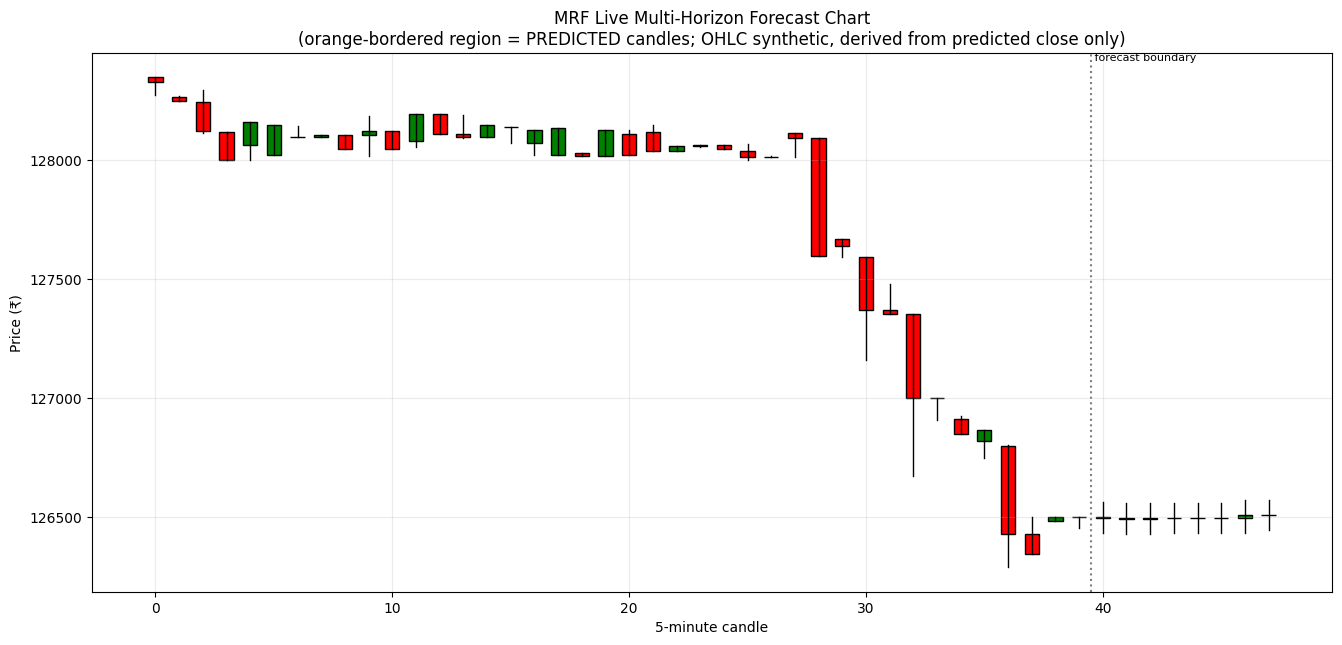

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

# 1. Establish strict timezone-aware system time
IST_tz = pytz.timezone(IST)
actual_now = datetime.now(IST_tz)

# 2. Fetch live/intraday candles safely
# We check intraday candles first for active session data, falling back to historical warm-up
try:
    completed_live = get_intraday_candles(INSTRUMENT_KEY, interval=BASE_TIMEFRAME_MINUTES)
    if completed_live.empty:
        completed_live = get_live_warmup_data(INSTRUMENT_KEY, interval=BASE_TIMEFRAME_MINUTES, warmup_days=LIVE_WARMUP_DAYS)
except Exception:
    completed_live = get_live_warmup_data(INSTRUMENT_KEY, interval=BASE_TIMEFRAME_MINUTES, warmup_days=LIVE_WARMUP_DAYS)

required_candles = LOOKBACK + MAX_STEP

if len(completed_live) < required_candles and not completed_live.empty:
    # Supplement tail to support LOOKBACK indicators
    temp_start = (actual_now - pd.Timedelta(days=5)).strftime("%Y-%m-%d")
    temp_end = actual_now.strftime("%Y-%m-%d")
    hist_tail = get_historical_candles(INSTRUMENT_KEY, temp_start, temp_end, interval=BASE_TIMEFRAME_MINUTES)
    if not hist_tail.empty:
        hist_tail = hist_tail[~hist_tail["Datetime"].isin(completed_live["Datetime"])]
        combined_df = pd.concat([hist_tail, completed_live], ignore_index=True)
        combined_df = combined_df.sort_values("Datetime").drop_duplicates(subset=["Datetime"]).reset_index(drop=True)
        completed_live = combined_df.tail(required_candles * 2)

# 3. Determine candle time and calculate Data Age
market_info = market_is_open()
market_open_status = "🟢 MARKET OPEN" if market_info["open"] else "🔴 MARKET CLOSED"

if completed_live.empty:
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print("SREE.AI LIVE SNAPSHOT")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
    print("🔴 NO MARKET DATA RETURNED FROM UPSTOX")
else:
    latest_completed_candle_time = completed_live["Datetime"].iloc[-1]
    if latest_completed_candle_time.tzinfo is None:
        latest_completed_candle_time = latest_completed_candle_time.tz_localize(IST_tz)
    else:
        latest_completed_candle_time = latest_completed_candle_time.tz_convert(IST_tz)

    data_age_seconds = (actual_now - latest_completed_candle_time).total_seconds()
    data_age_minutes = max(0, int(data_age_seconds // 60))

    # Strict Freshness Guard: If market is open and data is older than 3 intervals (15 mins)
    is_stale = market_info["open"] and (data_age_minutes > 15)

    print("━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print("SREE.AI LIVE SNAPSHOT")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
    print(STOCK_NAME)
    print(f"\nCurrent Time:\n{actual_now.strftime('%Y-%m-%d %H:%M:%S')} IST")
    print(f"\nLatest Completed Candle:\n{latest_completed_candle_time.strftime('%Y-%m-%d %H:%M')} IST")
    print(f"\nCurrent Price:\n₹{completed_live['Close'].iloc[-1]:.2f}")
    print(f"\nData Age:\n{data_age_minutes} minutes")
    print(f"\nMarket Status:\n{market_open_status}\n")

    if is_stale:
        print("━━━━━━━━━━━━━━━━━━━━━━━━━━")
        print("⚠️  STALE MARKET DATA")
        print("━━━━━━━━━━━━━━━━━━━━━━━━━━")
        print("Live predictions are suspended because the feed is lagging behind active trading hours.")
    elif len(completed_live) < required_candles:
        print(f"Insufficient history to compute indicators. Have {len(completed_live)}/ {required_candles}.")
    else:
        live_feat = build_live_features(completed_live)
        live_feat = live_feat.dropna(subset=FEATURE_COLUMNS)

        # Extract latest window and scale
        window_raw = live_feat[FEATURE_COLUMNS].values[-LOOKBACK:].astype(np.float32)
        window_scaled = scaler.transform(window_raw).astype(np.float32)
        current_price = float(live_feat["Close"].iloc[-1])

        # Model Inference
        gru_pred = gru_model.predict(window_scaled[np.newaxis, ...], verbose=0)[0]
        xgb_pred_vector = []
        for m in HORIZONS.keys():
            flat_features = flatten_for_xgb(window_scaled[np.newaxis, ...])
            xgb_pred_vector.append(float(xgb_models[m].predict(flat_features)[0]))

        predictions_table = []
        predicted_closes_path = []

        for j, (minutes, step) in enumerate(HORIZONS.items()):
            model_used = BEST_MODEL_PER_HORIZON[minutes]
            pred_return = float(gru_pred[j] if model_used == "GRU" else xgb_pred_vector[j])
            pred_price = current_price * np.exp(pred_return)
            predicted_closes_path.append(pred_price)
            val_acc = float(selection_df.loc[selection_df["Horizon_min"] == minutes, "GRU_val_acc_%"].values[0])

            predictions_table.append({
                "Horizon": f"{minutes} min",
                "Predicted Price": f"₹{pred_price:.2f}",
                "Expected Return %": f"{pred_return * 100:+.3f}%",
                "Validation Accuracy": f"{val_acc:.1f}%",
                "Model Used": model_used
            })

        display(pd.DataFrame(predictions_table))

        # Generate forecast chart
        _ = plot_forecast_chart(
            live_feat.tail(60),
            predicted_closes_path,
            horizon_minutes=60,
            title=f"{STOCK_NAME} Live Multi-Horizon Forecast Chart"
        )